# SGD Classifier - Online Batch Learning
Train SGDClassifier using year-based batches to simulate online learning scenario

In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
import warnings

## 1. Load Prepared Data and Split

In [9]:
# Load the prepared dataset with features
ds_path = Path('.') / 'training_data_with_features_plus_monthly_indices.zarr'
print(f'Loading data from {ds_path}...')
ds = xr.open_dataset(ds_path, engine='zarr')
print('✓ Data loaded')

# Load the train/val/test split
split_path = Path('.') / 'data_split.npz'
print(f'\nLoading split from {split_path}...')
split_data = np.load(split_path)
train_pixel_indices = split_data['train_pixel_indices']
val_pixel_indices = split_data['val_pixel_indices']
test_pixel_indices = split_data['test_pixel_indices']
print('✓ Split loaded')

print(f'\nDataset info:')
print(f'  Total pixels: {len(ds.pixel)}')
print(f'  Total years: {len(ds.year)}')
print(f'  Train pixels: {len(train_pixel_indices)}')
print(f'  Val pixels: {len(val_pixel_indices)}')
print(f'  Test pixels: {len(test_pixel_indices)}')

Loading data from training_data_with_features_plus_monthly_indices.zarr...
✓ Data loaded

Loading split from data_split.npz...
✓ Split loaded

Dataset info:
  Total pixels: 8155205
  Total years: 7
  Train pixels: 5597776
  Val pixels: 1273437
  Test pixels: 1283992


## 2. Feature Engineering
Prepare features from S2 bands, spectral indices, DEM, and temporal deltas

In [10]:
def prepare_features_for_year(ds, pixel_indices, year_idx, scaler=None, scaler_mode='auto'):

    """

    Extract and normalize features for a specific year and set of pixels.

    - Skips year 0 entirely (no features returned)

    - Fills S2 band NaNs with per-pixel mean across all years

    - Drops samples that still contain NaNs (e.g., pixels where all years are NaN)

    - Filters out invalid labels (keeps only 0 and 1, removes 255)

    - Adds temporal deltas starting from year 1 (2017), where year 1 delta = 2017 - 0



    Scaling modes:

        - 'auto': fit scaler if needed, otherwise transform (backward-compatible)

        - 'fit': fit scaler on this batch, then transform

        - 'partial_fit': update scaler on this batch, then transform

        - 'transform': transform with an already-fitted scaler

        - 'none': return cleaned but unscaled features



    Args:

        ds: xarray Dataset

        pixel_indices: array of pixel indices to extract

        year_idx: year index (0-based)

        scaler: StandardScaler instance (optional)

        scaler_mode: scaling behavior mode



    Returns:

        X: feature matrix (scaled unless scaler_mode='none')

        y: labels (n_pixels,)

        scaler: scaler used/updated (or unchanged when scaler_mode='none')

    """

    # Skip year 0 entirely

    if year_idx == 0:

        return np.empty((0, 0)), np.empty((0,)), scaler



    valid_scaler_modes = {'auto', 'fit', 'partial_fit', 'transform', 'none'}

    if scaler_mode not in valid_scaler_modes:

        raise ValueError(f"Invalid scaler_mode '{scaler_mode}'. Valid options: {sorted(valid_scaler_modes)}")



    # Precompute per-pixel S2 means across all years for imputation

    s2_all_years = ds['s2_bands'].isel(pixel=pixel_indices).values  # (pixels, year, band)

    s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)



    # Extract data for selected pixels and target year

    ds_subset = ds.isel(pixel=pixel_indices, year=year_idx)



    # S2 bands (flatten across bands)

    s2_features = ds_subset['s2_bands'].values  # (n_pixels, n_s2_bands)

    # Fill NaNs in S2 with per-pixel mean over years

    if np.isnan(s2_features).any():

        # Broadcast mean to same shape and fill

        s2_features = np.where(np.isnan(s2_features), s2_mean_per_pixel, s2_features)



    # DEM

    dem_features = ds_subset['dem'].values.reshape(-1, 1)  # (n_pixels, 1)



    # Spectral indices

    ndvi_features = ds_subset['ndvi'].values.reshape(-1, 1)

    ndwi_features = ds_subset['ndwi'].values.reshape(-1, 1)



    # Last-year features (year t-1)

    ds_prev = ds.isel(pixel=pixel_indices, year=year_idx - 1)

    ndvi_last_year = ds_prev['ndvi'].values.reshape(-1, 1)

    ndwi_last_year = ds_prev['ndwi'].values.reshape(-1, 1)

    ndvi_last_year = np.where(np.isnan(ndvi_last_year), 0, ndvi_last_year)

    ndwi_last_year = np.where(np.isnan(ndwi_last_year), 0, ndwi_last_year)



    # Last-year selected S2 bands

    required_last_year_bands = ['B04', 'B03', 'B06']

    band_to_idx = {band: i for i, band in enumerate(ds['s2_band'].values)}

    missing_bands = [band for band in required_last_year_bands if band not in band_to_idx]

    if missing_bands:

        raise ValueError(f"Missing required S2 bands for last-year features: {missing_bands}")



    last_year_s2_features = []

    for band in required_last_year_bands:

        band_values = ds_prev['s2_bands'].sel(s2_band=band).values  # (n_pixels,)

        if np.isnan(band_values).any():

            band_values = np.where(np.isnan(band_values), 0, band_values)

        last_year_s2_features.append(band_values.reshape(-1, 1))



    # Start with base features

    features_list = [

        s2_features,

        dem_features,

        ndvi_features,

        ndwi_features,

        ndvi_last_year,

        ndwi_last_year,

        *last_year_s2_features,

    ]



    # Add NBR if available

    if 'nbr' in ds.data_vars:

        nbr_features = ds_subset['nbr'].values.reshape(-1, 1)

        features_list.append(nbr_features)



    # Add temporal deltas if available

    # Delta starts from year 1: delta[0] = year[1] - 0 (2017 - 0)

    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:

        # Delta index is offset by 1: delta[0] = year[1] - 0

        delta_year_idx = year_idx - 1

        ds_delta = ds.isel(pixel=pixel_indices, year=delta_year_idx)

        ndvi_delta = ds_delta['ndvi_delta'].values.reshape(-1, 1)

        ndwi_delta = ds_delta['ndwi_delta'].values.reshape(-1, 1)

        features_list.extend([ndvi_delta, ndwi_delta])



        if 'nbr_delta' in ds.data_vars:

            nbr_delta = ds_delta['nbr_delta'].values.reshape(-1, 1)

            features_list.append(nbr_delta)



    # Add new temporal features (no data leakage - computed from prior years only)

    if 'years_since_last_disturbance' in ds.data_vars:

        years_since_features = ds_subset['years_since_last_disturbance'].values.reshape(-1, 1)

        features_list.append(years_since_features)



    if 'log_years_since_last_disturbance' in ds.data_vars:

        log_years_since_features = ds_subset['log_years_since_last_disturbance'].values.reshape(-1, 1)

        features_list.append(log_years_since_features)



    if 'ever_disturbed' in ds.data_vars:

        ever_disturbed_features = ds_subset['ever_disturbed'].values.reshape(-1, 1)

        features_list.append(ever_disturbed_features)



    # Add yearly index summary features (current year, no leakage)

    yearly_index_feature_names = [

        'ndvi_cv_year',

        'ndvi_max_m2m_drop_year',

        'ndvi_max_year',

        'ndvi_min_year',

        'ndvi_std_year',

        'ndwi_cv_year',

        'ndwi_max_m2m_drop_year',

        'ndwi_max_year',

        'ndwi_min_year',

        'ndwi_std_year',

    ]

    available_yearly_features = []

    for feature_name in yearly_index_feature_names:

        if feature_name in ds.data_vars:

            feature_values = ds_subset[feature_name].values.reshape(-1, 1)

            features_list.append(feature_values)

            available_yearly_features.append(feature_name)



    # Concatenate all features

    X = np.concatenate(features_list, axis=1)



    # Labels

    y = ds_subset['disturbances'].values



    # Filter out invalid labels (keep only 0 and 1, remove 255)

    valid_label_mask = np.isin(y, [0, 1])

    X = X[valid_label_mask]

    y = y[valid_label_mask]



    n_invalid_labels = (~valid_label_mask).sum()

    if n_invalid_labels > 0:

        print(f'  Dropped {n_invalid_labels} samples with invalid labels (class 255) for year {year_idx}')



    # Drop samples with any remaining NaN (e.g., pixels whose all-year S2 were NaN)

    nan_mask = ~np.isnan(X).any(axis=1)

    X_clean = X[nan_mask]

    y_clean = y[nan_mask]



    n_dropped = len(X) - len(X_clean)

    if n_dropped > 0:

        print(f'  Dropped {n_dropped} samples with NaN values ({100*n_dropped/len(X):.1f}%) for year {year_idx}')



    # If nothing left, return empty arrays

    if len(X_clean) == 0:

        return np.empty((0, X.shape[1] if X.shape[0] > 0 else 0)), np.empty((0,)), scaler



    # Scaling behavior

    if scaler_mode == 'none':

        return X_clean, y_clean, scaler



    if scaler is None:

        scaler = StandardScaler()



    if scaler_mode == 'auto':

        if hasattr(scaler, 'mean_'):

            X_clean = scaler.transform(X_clean)

        else:

            X_clean = scaler.fit_transform(X_clean)

            print(f'  ✓ Fitted scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')

    elif scaler_mode == 'fit':

        X_clean = scaler.fit_transform(X_clean)

        print(f'  ✓ Fitted scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')

    elif scaler_mode == 'partial_fit':

        scaler.partial_fit(X_clean)

        X_clean = scaler.transform(X_clean)

        print(f'  ✓ Incrementally updated scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')

    elif scaler_mode == 'transform':

        if not hasattr(scaler, 'mean_'):

            raise ValueError("Scaler must be fitted before using scaler_mode='transform'.")

        X_clean = scaler.transform(X_clean)



    return X_clean, y_clean, scaler

In [11]:
# Sanity check: verify new yearly features exist and feature dimensions are stable

expected_new_features = [

    'ndvi_cv_year',

    'ndvi_max_m2m_drop_year',

    'ndvi_max_year',

    'ndvi_min_year',

    'ndvi_std_year',

    'ndwi_cv_year',

    'ndwi_max_m2m_drop_year',

    'ndwi_max_year',

    'ndwi_min_year',

    'ndwi_std_year',

]



missing_new_features = [f for f in expected_new_features if f not in ds.data_vars]

if missing_new_features:

    raise ValueError(f'Missing expected yearly features in dataset: {missing_new_features}')



X_train_check, y_train_check, _ = prepare_features_for_year(

    ds,

    train_pixel_indices[:10000],

    year_idx=1,

    scaler=None,

    scaler_mode='none',

)

X_val_check, y_val_check, _ = prepare_features_for_year(

    ds,

    val_pixel_indices[:10000],

    year_idx=1,

    scaler=None,

    scaler_mode='none',

)



print('Yearly feature presence check: OK')

print(f'Quick train sample shape: X={X_train_check.shape}, y={y_train_check.shape}')

print(f'Quick val sample shape:   X={X_val_check.shape}, y={y_val_check.shape}')



if X_train_check.shape[1] != X_val_check.shape[1]:

    raise ValueError(

        f'Feature dimension mismatch between train and val: '

        f'{X_train_check.shape[1]} vs {X_val_check.shape[1]}'

    )



print(f'Feature dimension consistency check passed: {X_train_check.shape[1]} features')

  Dropped 1 samples with NaN values (0.0%) for year 1
Yearly feature presence check: OK
Quick train sample shape: X=(9999, 32), y=(9999,)
Quick val sample shape:   X=(10000, 32), y=(10000,)
Feature dimension consistency check passed: 32 features


In [12]:
# Data Overview and Diagnostic Check
print('='*80)
print('DATA OVERVIEW AND QUALITY CHECK')
print('='*80)

# 1. Dataset shape and variables
print('\n1. Dataset Structure:')
print(f'   Total pixels: {len(ds.pixel)}')
print(f'   Total years: {len(ds.year)} (values: {ds.year.values})')
print(f'   Total S2 bands: {len(ds.s2_band)} (bands: {ds.s2_band.values})')
print(f'   Variables: {list(ds.data_vars.keys())}')

# 2. Sample a subset of pixels for detailed analysis
sample_pixels = train_pixel_indices[:1000]
print(f'\n2. Analyzing {len(sample_pixels)} sample training pixels...')

# 3. Check NaN statistics per variable and year
print('\n3. NaN Statistics by Year (All Features):')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    ds_year = ds.isel(pixel=sample_pixels, year=year_idx)
    
    print(f'\n   Year {year_val} (idx={year_idx}):')
    
    # S2 bands
    s2_nan_count = np.isnan(ds_year['s2_bands'].values).sum()
    s2_total = ds_year['s2_bands'].values.size
    print(f'     S2 bands: {s2_nan_count}/{s2_total} ({100*s2_nan_count/s2_total:.1f}%) NaN')
    
    # DEM
    dem_nan_count = np.isnan(ds_year['dem'].values).sum()
    dem_total = len(sample_pixels)
    print(f'     DEM: {dem_nan_count}/{dem_total} ({100*dem_nan_count/dem_total:.1f}%) NaN')
    
    # NDVI
    ndvi_nan_count = np.isnan(ds_year['ndvi'].values).sum()
    ndvi_total = len(sample_pixels)
    print(f'     NDVI: {ndvi_nan_count}/{ndvi_total} ({100*ndvi_nan_count/ndvi_total:.1f}%) NaN')
    
    # NDWI
    ndwi_nan_count = np.isnan(ds_year['ndwi'].values).sum()
    ndwi_total = len(sample_pixels)
    print(f'     NDWI: {ndwi_nan_count}/{ndwi_total} ({100*ndwi_nan_count/ndwi_total:.1f}%) NaN')
    
    # NBR
    if 'nbr' in ds.data_vars:
        nbr_nan_count = np.isnan(ds_year['nbr'].values).sum()
        nbr_total = len(sample_pixels)
        print(f'     NBR: {nbr_nan_count}/{nbr_total} ({100*nbr_nan_count/nbr_total:.1f}%) NaN')
    
    # Temporal deltas (if available and not the first year)
    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        ds_delta = ds.isel(pixel=sample_pixels, year=year_idx-1)
        ndvi_delta_nan_count = np.isnan(ds_delta['ndvi_delta'].values).sum()
        ndvi_delta_total = len(sample_pixels)
        print(f'     NDVI_delta: {ndvi_delta_nan_count}/{ndvi_delta_total} ({100*ndvi_delta_nan_count/ndvi_delta_total:.1f}%) NaN')
        
        ndwi_delta_nan_count = np.isnan(ds_delta['ndwi_delta'].values).sum()
        ndwi_delta_total = len(sample_pixels)
        print(f'     NDWI_delta: {ndwi_delta_nan_count}/{ndwi_delta_total} ({100*ndwi_delta_nan_count/ndwi_delta_total:.1f}%) NaN')
        
        if 'nbr_delta' in ds.data_vars:
            nbr_delta_nan_count = np.isnan(ds_delta['nbr_delta'].values).sum()
            nbr_delta_total = len(sample_pixels)
            print(f'     NBR_delta: {nbr_delta_nan_count}/{nbr_delta_total} ({100*nbr_delta_nan_count/nbr_delta_total:.1f}%) NaN')

# 4. Check S2 per-pixel mean imputation coverage
print('\n4. S2 Imputation Analysis:')
s2_all = ds['s2_bands'].isel(pixel=sample_pixels).values  # (pixels, years, bands)
s2_mean_per_pixel = np.nanmean(s2_all, axis=1)  # (pixels, band)
pixels_all_nan = np.isnan(s2_mean_per_pixel).all(axis=1).sum()
print(f'   Pixels with all-NaN S2 across all years: {pixels_all_nan}/{len(sample_pixels)} ({100*pixels_all_nan/len(sample_pixels):.1f}%)')
print(f'   These pixels will be dropped after imputation.')

# 5. Temporal delta availability
if 'ndvi_delta' in ds.data_vars:
    print('\n5. Temporal Delta Features:')
    print(f'   Delta variables available: NDVI_delta, NDWI_delta' + (', NBR_delta' if 'nbr_delta' in ds.data_vars else ''))
    print(f'   Delta has shape: {ds["ndvi_delta"].shape} (one less year than original)')

# 6. Class distribution (positive/negative percentages)
print('\n6. Disturbance Class Distribution:')
print('-' * 80)
dist_all = ds['disturbances'].isel(pixel=sample_pixels).values.flatten()
unique, counts = np.unique(dist_all, return_counts=True)
for val, count in zip(unique, counts):
    class_name = 'No Disturbance' if int(val) == 0 else 'Disturbance'
    percentage = 100 * count / len(dist_all)
    print(f'   Class {int(val)} ({class_name}): {count} ({percentage:.2f}%)')

# 7. Per-year disturbance distribution
print('\n7. Disturbance Distribution by Year:')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    dist_year = ds['disturbances'].isel(pixel=sample_pixels, year=year_idx).values
    class_0_count = (dist_year == 0).sum()
    class_1_count = (dist_year == 1).sum()
    total = len(dist_year)
    print(f'   Year {year_val}:')
    print(f'     No Disturbance: {class_0_count}/{total} ({100*class_0_count/total:.2f}%)')
    print(f'     Disturbance: {class_1_count}/{total} ({100*class_1_count/total:.2f}%)')

# 8. Test one year in detail (year 1)
print('\n8. Detailed Check for Year 1:')
ds_y1 = ds.isel(pixel=sample_pixels, year=1)
s2_y1 = ds_y1['s2_bands'].values
dem_y1 = ds_y1['dem'].values
ndvi_y1 = ds_y1['ndvi'].values
ndwi_y1 = ds_y1['ndwi'].values

# After imputation simulation
s2_y1_imputed = np.where(np.isnan(s2_y1), s2_mean_per_pixel, s2_y1)
all_features_y1 = np.concatenate([
    s2_y1_imputed, 
    dem_y1.reshape(-1, 1), 
    ndvi_y1.reshape(-1, 1),
    ndwi_y1.reshape(-1, 1)
], axis=1)

nan_mask_y1 = ~np.isnan(all_features_y1).any(axis=1)
remaining_y1 = nan_mask_y1.sum()
dropped_y1 = len(sample_pixels) - remaining_y1

print(f'   After S2 imputation: {remaining_y1}/{len(sample_pixels)} samples remain ({100*remaining_y1/len(sample_pixels):.1f}%)')
print(f'   Would drop: {dropped_y1} samples ({100*dropped_y1/len(sample_pixels):.1f}%)')

print('\n' + '='*80)
print('✓ Data overview complete. Review statistics before training.')
print('='*80)

DATA OVERVIEW AND QUALITY CHECK

1. Dataset Structure:
   Total pixels: 8155205
   Total years: 7 (values: [2016 2017 2018 2019 2020 2021 2022])
   Total S2 bands: 7 (bands: ['B02' 'B03' 'B04' 'B05' 'B06' 'B07' 'B8A'])
   Variables: ['cube_idx', 'cube_name', 'dem', 'disturbances', 'ever_disturbed', 'log_years_since_last_disturbance', 'nbr', 'nbr_delta', 'ndvi', 'ndvi_cv_year', 'ndvi_delta', 'ndvi_max_m2m_drop_year', 'ndvi_max_year', 'ndvi_min_year', 'ndvi_std_year', 'ndwi', 'ndwi_cv_year', 'ndwi_delta', 'ndwi_max_m2m_drop_year', 'ndwi_max_year', 'ndwi_min_year', 'ndwi_std_year', 's2_bands', 'x', 'y', 'year_disturbance', 'years_since_last_disturbance']

2. Analyzing 1000 sample training pixels...

3. NaN Statistics by Year (All Features):
--------------------------------------------------------------------------------

   Year 2016 (idx=0):
     S2 bands: 7000/7000 (100.0%) NaN
     DEM: 0/1000 (0.0%) NaN
     NDVI: 1000/1000 (100.0%) NaN
     NDWI: 1000/1000 (100.0%) NaN
     NBR: 1000

## 3. Initialize SGD Classifier

In [13]:
from sklearn.utils.class_weight import compute_class_weight



# Compute class weights from the full training data

# Sample across all years to get representative class distribution

print('Computing class weights from training data...')

all_train_labels = []

for year_idx in range(1, len(ds.year)):

    _, y_batch, _ = prepare_features_for_year(

        ds,

        train_pixel_indices,

        year_idx,

        scaler=None,

        scaler_mode='none',

    )

    if len(y_batch) > 0:

        all_train_labels.extend(y_batch)



all_train_labels = np.array(all_train_labels)

initial_count = len(all_train_labels)



# Remove any NaN values and convert to int

all_train_labels = all_train_labels[~np.isnan(all_train_labels)].astype(int)

after_nan_removal = len(all_train_labels)

nan_removed = initial_count - after_nan_removal



# Filter out invalid class 255 (keep only 0 and 1)

valid_mask = np.isin(all_train_labels, [0, 1])

all_train_labels = all_train_labels[valid_mask]

after_class_filter = len(all_train_labels)

class_255_removed = after_nan_removal - after_class_filter



print(f'\nLabel filtering summary:')

print(f'  Initial labels: {initial_count}')

print(f'  Removed NaN: {nan_removed}')

print(f'  Removed class 255: {class_255_removed}')

print(f'  Final valid labels: {after_class_filter}')



if len(all_train_labels) == 0:

    raise ValueError('No valid training labels after filtering! Check data quality.')



classes = np.array([0, 1])



print(f'\nCollected {len(all_train_labels)} training labels')

print(f'Unique classes in data: {np.unique(all_train_labels)}')



# Compute balanced class weights

class_weights_array = compute_class_weight('balanced', classes=classes, y=all_train_labels)

class_weight_dict = {classes[i]: class_weights_array[i] for i in range(len(classes))}



print(f'\nClass weights computed:')

print(f'  Class 0 (no disturbance): {class_weight_dict[0]:.4f}')

print(f'  Class 1 (disturbance): {class_weight_dict[1]:.4f}')

print(f'  Ratio (1:0): {class_weight_dict[1]/class_weight_dict[0]:.2f}x')



# Initialize SGD Classifier WITHOUT class_weight (not supported by partial_fit)

model = SGDClassifier(

    loss='log_loss',              # Logistic regression (gives probabilities)

    penalty='l2',                 # L2 regularization

    alpha=0.0001,                 # Regularization strength

    random_state=42,

    n_jobs=-1,                    # Use all CPU cores

    learning_rate='optimal',      # Optimal learning rate

    max_iter=1000,                # Max iterations per partial_fit

    tol=1e-3,                     # Tolerance for stopping

    warm_start=False,             # Don't preserve state between calls

    verbose=0

)



print(f'\n✓ SGD Classifier initialized with settings:')

print(f'  Loss: {model.loss}')

print(f'  Penalty: {model.penalty}')

print(f'  Class weights: Will be applied via sample_weight in partial_fit')

print(f'  Learning rate: {model.learning_rate}')

Computing class weights from training data...


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 21401 samples with NaN values (0.4%) for year 1
  Dropped 727 samples with invalid labels (class 255) for year 2
  Dropped 10242 samples with NaN values (0.2%) for year 2
  Dropped 727 samples with invalid labels (class 255) for year 3
  Dropped 10278 samples with NaN values (0.2%) for year 3
  Dropped 727 samples with invalid labels (class 255) for year 4
  Dropped 9657 samples with NaN values (0.2%) for year 4
  Dropped 727 samples with invalid labels (class 255) for year 5
  Dropped 10194 samples with NaN values (0.2%) for year 5
  Dropped 727 samples with invalid labels (class 255) for year 6
  Dropped 4969 samples with NaN values (0.1%) for year 6

Label filtering summary:
  Initial labels: 33515553
  Removed NaN: 0
  Removed class 255: 0
  Final valid labels: 33515553

Collected 33515553 training labels
Unique classes in data: [0 1]

Class weights computed:
  Class 0 (no disturbance): 0.5105
  Class 1 (dis

## 4. Online Training Loop (Year-by-Year Batches)

In [14]:
import pickle

import copy

from pathlib import Path



OUTPUT_SUFFIX = 'incremental_scaler'

MODELS_DIR_NAME = f'models_prevyears_monthly_features_{OUTPUT_SUFFIX}'

SCALER_FILE_TEMPLATE = f'scaler_year_{{year}}_prevyears_monthly_features_{OUTPUT_SUFFIX}.pkl'

MODEL_FILE_TEMPLATE = f'model_year_{{year}}_prevyears_monthly_features_{OUTPUT_SUFFIX}.pkl'

FINAL_SCALER_FILENAME = f'scaler_final_prevyears_monthly_features_{OUTPUT_SUFFIX}.pkl'



# Create models directory if it doesn't exist

models_dir = Path('.') / MODELS_DIR_NAME

models_dir.mkdir(exist_ok=True)

print(f'✓ Models directory: {models_dir.absolute()}')

print(f'✓ Scaler file pattern: {SCALER_FILE_TEMPLATE}')

print(f'✓ Model file pattern: {MODEL_FILE_TEMPLATE}')


✓ Models directory: c:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features_incremental_scaler
✓ Scaler file pattern: scaler_year_{year}_prevyears_monthly_features_incremental_scaler.pkl
✓ Model file pattern: model_year_{year}_prevyears_monthly_features_incremental_scaler.pkl


In [15]:
# Training history tracking

training_history = {

    'year': [],

    'train_accuracy': [],

    'train_precision': [],

    'train_recall': [],

    'train_f1': [],

    'val_accuracy': [],

    'val_precision': [],

    'val_recall': [],

    'val_f1': [],

    'val_roc_auc': [],

    'val_pr_auc': []

}



n_years = len(ds.year)

year_values = ds.year.values



# Use one running scaler and update it incrementally year-by-year

print('Using incremental scaler: one running scaler updated year-by-year and checkpointed per year.')

incremental_scaler = StandardScaler()

year_to_scaler_checkpoint = {}



# Mini-batch and multi-epoch training configuration

CHUNK_SIZE = 50000  # Mini-batch size

MAX_EPOCHS = 15     # Maximum epochs per year

PATIENCE = 3        # Early stopping patience (epochs)

MIN_DELTA = 0.0005  # Minimum improvement in PR-AUC to reset patience



print(f'Training Configuration:')

print(f'  Chunk size: {CHUNK_SIZE:,} samples')

print(f'  Max epochs per year: {MAX_EPOCHS}')

print(f'  Early stopping patience: {PATIENCE} epochs')

print(f'  Min PR-AUC improvement: {MIN_DELTA}\n')



print(f'Starting online training with years 1..{n_years-1} (year 0 skipped)...\n')



for year_idx in tqdm(range(1, n_years), desc='Training by year'):

    year_val = year_values[year_idx]



    # Prepare training batch and incrementally update scaler using this year's training data

    X_train_batch, y_train_batch, incremental_scaler = prepare_features_for_year(

        ds,

        train_pixel_indices,

        year_idx,

        scaler=incremental_scaler,

        scaler_mode='partial_fit',

    )



    # Prepare validation data using the same scaler state as this year model

    X_val_batch, y_val_batch, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        year_idx,

        scaler=incremental_scaler,

        scaler_mode='transform',

    )



    # Skip if no data available for this year

    if len(X_train_batch) == 0 or len(X_val_batch) == 0:

        print(f'Year {year_val}: skipped (no samples after NaN handling)')

        continue



    # Persist scaler checkpoint for this year

    scaler_checkpoint = copy.deepcopy(incremental_scaler)

    year_to_scaler_checkpoint[year_val] = scaler_checkpoint

    year_scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    with open(year_scaler_path, 'wb') as f:

        pickle.dump(scaler_checkpoint, f)

    print(f'  ✓ Incremental scaler checkpoint saved to {year_scaler_path.name}')



    # Split training batch into chunks

    n_samples = len(X_train_batch)

    n_chunks = max(1, int(np.ceil(n_samples / CHUNK_SIZE)))



    # Track best validation PR-AUC for early stopping

    best_val_pr_auc = -np.inf

    patience_counter = 0

    best_model_state = None



    print(f'\nYear {year_val}: {n_samples:,} samples, {n_chunks} chunks')



    # Multi-epoch training

    for epoch in range(MAX_EPOCHS):

        # Shuffle indices for this epoch

        shuffle_idx = np.random.permutation(n_samples)

        X_train_shuffled = X_train_batch[shuffle_idx]

        y_train_shuffled = y_train_batch[shuffle_idx]



        # Process chunks

        for chunk_idx in range(n_chunks):

            start_idx = chunk_idx * CHUNK_SIZE

            end_idx = min(start_idx + CHUNK_SIZE, n_samples)



            X_chunk = X_train_shuffled[start_idx:end_idx]

            y_chunk = y_train_shuffled[start_idx:end_idx]



            # Compute sample weights for this chunk

            sample_weights_chunk = np.array([class_weight_dict[int(label)] for label in y_chunk])



            # Incremental fit on chunk

            classes = np.array([0, 1])

            model.partial_fit(X_chunk, y_chunk, classes=classes, sample_weight=sample_weights_chunk)



        # Evaluate on validation after each epoch

        y_val_pred = model.predict(X_val_batch)

        y_val_proba = model.predict_proba(X_val_batch)[:, 1]



        val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)

        val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)

        val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)



        if len(np.unique(y_val_batch)) > 1:

            val_pr_auc = average_precision_score(y_val_batch, y_val_proba)

        else:

            val_pr_auc = np.nan



        # Early stopping check

        if val_pr_auc > best_val_pr_auc + MIN_DELTA:

            best_val_pr_auc = val_pr_auc

            patience_counter = 0

            # Save best model state

            best_model_state = {

                'coef': model.coef_.copy(),

                'intercept': model.intercept_.copy(),

                't_': model.t_

            }

            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} ✓ (improved)')

        else:

            patience_counter += 1

            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} (no improvement, patience={patience_counter}/{PATIENCE})')



            if patience_counter >= PATIENCE:

                print(f'  Early stopping triggered. Restoring best model.')

                # Restore best model state

                if best_model_state is not None:

                    model.coef_ = best_model_state['coef']

                    model.intercept_ = best_model_state['intercept']

                    model.t_ = best_model_state['t_']

                break



    # Final evaluation on training and validation

    y_train_pred = model.predict(X_train_batch)

    train_acc = accuracy_score(y_train_batch, y_train_pred)

    train_prec = precision_score(y_train_batch, y_train_pred, zero_division=0)

    train_rec = recall_score(y_train_batch, y_train_pred, zero_division=0)

    train_f1 = f1_score(y_train_batch, y_train_pred, zero_division=0)



    y_val_pred = model.predict(X_val_batch)

    y_val_proba = model.predict_proba(X_val_batch)[:, 1]

    val_acc = accuracy_score(y_val_batch, y_val_pred)

    val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)

    val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)

    val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)



    if len(np.unique(y_val_batch)) > 1:

        val_roc_auc = roc_auc_score(y_val_batch, y_val_proba)

        val_pr_auc = average_precision_score(y_val_batch, y_val_proba)

    else:

        val_roc_auc = np.nan

        val_pr_auc = np.nan



    # Store metrics

    training_history['year'].append(year_val)

    training_history['train_accuracy'].append(train_acc)

    training_history['train_precision'].append(train_prec)

    training_history['train_recall'].append(train_rec)

    training_history['train_f1'].append(train_f1)

    training_history['val_accuracy'].append(val_acc)

    training_history['val_precision'].append(val_prec)

    training_history['val_recall'].append(val_rec)

    training_history['val_f1'].append(val_f1)

    training_history['val_roc_auc'].append(val_roc_auc)

    training_history['val_pr_auc'].append(val_pr_auc)



    # Save model for this year

    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    with open(year_model_path, 'wb') as f:

        pickle.dump(model, f)



    # Print summary for this year

    print(

        f'  Final: Train F1={train_f1:.3f}, Val F1={val_f1:.3f}, '

        f'Val Precision={val_prec:.3f}, Val Recall={val_rec:.3f}, Val PR-AUC={val_pr_auc:.3f}'

    )

    print(f'  ✓ Model saved to {year_model_path.name}')



if hasattr(incremental_scaler, 'mean_'):

    final_scaler_path = models_dir / FINAL_SCALER_FILENAME

    with open(final_scaler_path, 'wb') as f:

        pickle.dump(incremental_scaler, f)

    print(f'✓ Final incremental scaler saved to {final_scaler_path.name}')



print('\n✓ Training complete!')

Using incremental scaler: one running scaler updated year-by-year and checkpointed per year.
Training Configuration:
  Chunk size: 50,000 samples
  Max epochs per year: 15
  Early stopping patience: 3 epochs
  Min PR-AUC improvement: 0.0005

Starting online training with years 1..6 (year 0 skipped)...



Training by year:   0%|          | 0/6 [00:00<?, ?it/s]

C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 21401 samples with NaN values (0.4%) for year 1
  ✓ Incrementally updated scaler on year 1 (5575648 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


...

  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1697 samples with NaN values (0.1%) for year 5
  ✓ Incremental scaler checkpoint saved to scaler_year_2021_prevyears_monthly_features_incremental_scaler.pkl

Year 2021: 5,586,855 samples, 112 chunks
  Epoch 1/15: Val PR-AUC=0.3836 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.3754 (no improvement, patience=1/3)
  Epoch 3/15: Val PR-AUC=0.3698 (no improvement, patience=2/3)
  Epoch 4/15: Val PR-AUC=0.3727 (no improvement, patience=3/3)
  Early stopping triggered. Restoring best model.
  Final: Train F1=0.201, Val F1=0.193, Val Precision=0.112, Val Recall=0.711, Val PR-AUC=0.384
  ✓ Model saved to model_year_2021_prevyears_monthly_features_incremental_scaler.pkl


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 6
  Dropped 4969 samples with NaN values (0.1%) for year 6
  ✓ Incrementally updated scaler on year 6 (5592080 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6
  ✓ Incremental scaler checkpoint saved to scaler_year_2022_prevyears_monthly_features_incremental_scaler.pkl

Year 2022: 5,592,080 samples, 112 chunks
  Epoch 1/15: Val PR-AUC=0.2876 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.2882 ✓ (improved)
  Epoch 3/15: Val PR-AUC=0.2812 (no improvement, patience=1/3)
  Epoch 4/15: Val PR-AUC=0.2892 ✓ (improved)
  Epoch 5/15: Val PR-AUC=0.2843 (no improvement, patience=1/3)
  Epoch 6/15: Val PR-AUC=0.2846 (no improvement, patience=2/3)
  Epoch 7/15: Val PR-AUC=0.2881 (no improvement, patience=3/3)
  Early stopping triggered. Restoring best model.
  Final: Train F1=0.176, Val F1=0.156, Val Precision=0.087, Val Recall=0.778, Val PR-AUC=0.289
  ✓ Model saved to model_year_2022_prevyears_monthly_features_incremental_scaler.pkl
✓ Final incremental scaler saved to scaler_final_prevyears_monthly_features_incremental_scaler.pkl

✓ Training

## 5. Visualize Learning Progress

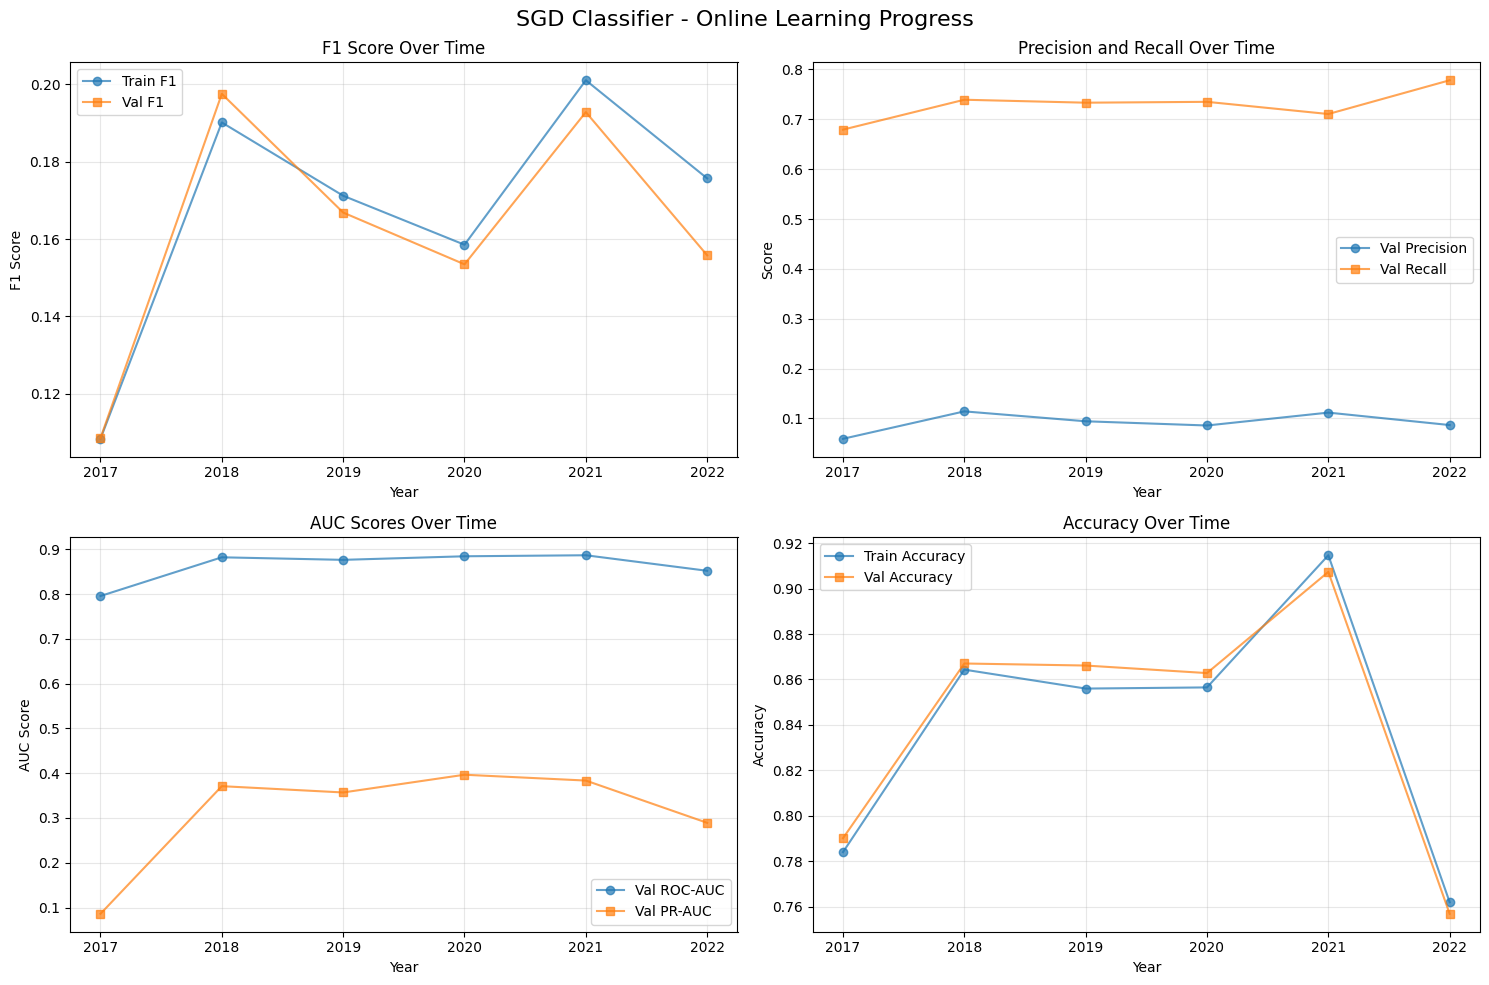


Summary Statistics (Validation Set):
       val_accuracy  val_precision  val_recall    val_f1  val_roc_auc  \
count      6.000000       6.000000    6.000000  6.000000     6.000000   
mean       0.841721       0.091826    0.729359  0.162519     0.862754   
std        0.056307       0.020147    0.032885  0.032257     0.035240   
min        0.756860       0.058997    0.679312  0.108565     0.795594   
25%        0.808299       0.085909    0.716333  0.154067     0.857980   
50%        0.864476       0.090359    0.734242  0.161342     0.879125   
75%        0.866812       0.107198    0.738264  0.186339     0.883692   
max        0.907350       0.114008    0.778390  0.197552     0.886532   

       val_pr_auc  
count    6.000000  
mean     0.313915  
std      0.117729  
min      0.086121  
25%      0.306156  
50%      0.364013  
75%      0.380438  
max      0.396561  


In [16]:
# Convert history to DataFrame
history_df = pd.DataFrame(training_history)

# Plot learning curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SGD Classifier - Online Learning Progress', fontsize=16)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(history_df['year'], history_df['train_f1'], label='Train F1', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_f1'], label='Val F1', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(history_df['year'], history_df['val_precision'], label='Val Precision', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_recall'], label='Val Recall', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: ROC-AUC and PR-AUC
ax = axes[1, 0]
ax.plot(history_df['year'], history_df['val_roc_auc'], label='Val ROC-AUC', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_pr_auc'], label='Val PR-AUC', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Accuracy
ax = axes[1, 1]
ax.plot(history_df['year'], history_df['train_accuracy'], label='Train Accuracy', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_accuracy'], label='Val Accuracy', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display summary statistics
print('\nSummary Statistics (Validation Set):')
print(history_df[['val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_roc_auc', 'val_pr_auc']].describe())

## 6. Final Evaluation on Test Set

In [17]:
# Shared utilities for dynamic thresholding across evaluation sections
from sklearn.metrics import precision_recall_curve


def _compute_best_f1_threshold(y_true, y_score, default_threshold=0.5):
    """Return PR-curve threshold that maximizes F1, with a safe fallback."""
    if len(y_true) == 0 or len(np.unique(y_true)) <= 1:
        return float(default_threshold), 'fallback_single_class_or_empty'

    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_score)
    f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
    best_idx = int(np.argmax(f1_vals))

    if best_idx < len(thresholds):
        return float(thresholds[best_idx]), 'computed_pr_f1'

    return float(default_threshold), 'fallback_terminal_pr_point'


def _load_year_scaler(year_val):
    """Load scaler checkpoint for a year, with in-memory fallback."""
    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            return pickle.load(f)

    return globals().get('year_to_scaler_checkpoint', {}).get(year_val)


def _get_or_create_threshold_maps():
    """Ensure threshold maps exist and normalize year keys to int when possible."""
    pair_map_raw = globals().get('model_eval_year_thresholds')
    if not isinstance(pair_map_raw, dict):
        pair_map_raw = {}

    model_map_raw = globals().get('model_year_thresholds')
    if not isinstance(model_map_raw, dict):
        model_map_raw = {}

    normalized_pair = {}
    for mk, eval_map in pair_map_raw.items():
        try:
            mk_int = int(mk)
        except Exception:
            continue

        if not isinstance(eval_map, dict):
            continue

        normalized_pair[mk_int] = {}
        for ek, val in eval_map.items():
            try:
                ek_int = int(ek)
                normalized_pair[mk_int][ek_int] = float(val)
            except Exception:
                continue

    normalized_model = {}
    for mk, val in model_map_raw.items():
        try:
            normalized_model[int(mk)] = float(val)
        except Exception:
            continue

    globals()['model_eval_year_thresholds'] = normalized_pair
    globals()['model_year_thresholds'] = normalized_model

    return normalized_pair, normalized_model


def _compute_eval_year_threshold_for_model(year_model, eval_year_idx, eval_scaler, default_threshold=0.5):
    """Compute threshold for one model/eval-year pair from eval-year validation data."""
    if 'val_pixel_indices' not in globals():
        return float(default_threshold), 'fallback_global_no_val'

    X_val_year, y_val_year, _ = prepare_features_for_year(
        ds,
        val_pixel_indices,
        eval_year_idx,
        scaler=eval_scaler,
        scaler_mode='transform',
    )

    if len(X_val_year) == 0:
        return float(default_threshold), 'fallback_global_no_val_samples'

    y_val_proba = year_model.predict_proba(X_val_year)[:, 1]
    threshold, source = _compute_best_f1_threshold(y_val_year, y_val_proba, default_threshold)

    return threshold, source


def resolve_dynamic_threshold(
    year_model,
    model_year_val,
    eval_year_val,
    eval_year_idx,
    eval_scaler,
    default_threshold=0.5,
    persist=True,
):
    """
    Resolve threshold with fallback order:
      1) pair-specific (model_year, eval_year)
      2) model-year threshold
      3) computed on eval-year validation (if possible)
      4) global fallback
    """
    pair_map, model_map = _get_or_create_threshold_maps()

    model_key = int(model_year_val)
    eval_key = int(eval_year_val)

    if model_key in pair_map and eval_key in pair_map[model_key]:
        return float(pair_map[model_key][eval_key]), 'pair_specific_saved'

    if model_key in model_map:
        return float(model_map[model_key]), 'model_year_saved'

    threshold, source = _compute_eval_year_threshold_for_model(
        year_model,
        eval_year_idx,
        eval_scaler,
        default_threshold,
    )

    if persist:
        pair_map.setdefault(model_key, {})[eval_key] = float(threshold)
        if model_key == eval_key:
            model_map[model_key] = float(threshold)

    return float(threshold), source


def get_global_dynamic_threshold(default_threshold=0.5, force_recompute=False):
    """Compute/reuse a global threshold from validation PR curve across years."""
    best_threshold_val = globals().get('best_threshold')
    if not force_recompute and best_threshold_val is not None:
        return float(best_threshold_val), 'best_threshold_cached'

    if 'model' not in globals():
        return float(default_threshold), 'fallback_no_model'

    y_val_all = []
    y_val_proba_all = []

    for year_idx in range(1, n_years):
        year_val = year_values[year_idx]
        year_scaler = _load_year_scaler(year_val)
        if year_scaler is None:
            continue

        X_val_year, y_val_year, _ = prepare_features_for_year(
            ds,
            val_pixel_indices,
            year_idx,
            scaler=year_scaler,
            scaler_mode='transform',
        )

        if len(X_val_year) == 0:
            continue

        y_val_all.append(y_val_year)
        y_val_proba_all.append(model.predict_proba(X_val_year)[:, 1])

    if len(y_val_all) == 0:
        return float(default_threshold), 'fallback_no_val_data'

    y_val_concat = np.concatenate(y_val_all)
    y_val_proba_concat = np.concatenate(y_val_proba_all)
    threshold, source = _compute_best_f1_threshold(y_val_concat, y_val_proba_concat, default_threshold)

    globals()['best_threshold'] = float(threshold)
    return float(threshold), f'global_{source}'

In [ ]:
# Evaluate on entire test set (years 1..end, year 0 skipped) with incremental scaler checkpoints

print('Evaluating on test set...')


decision_threshold, threshold_meta = get_global_dynamic_threshold(default_threshold=0.5)
threshold_source = threshold_meta['source']
globals()['test_set_threshold_meta'] = threshold_meta.copy()
print(f"Using decision threshold: {decision_threshold:.4f} ({threshold_source})\n")


y_test_all = []
y_pred_all = []
y_proba_all = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]

    # Load year-specific scaler checkpoint
    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        # Fallback to in-memory scaler checkpoints (if training ran in this session)
        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)

    if year_scaler is None:
        print(f'Year {year_val}: scaler checkpoint not found, skipping this year in test evaluation.')
        continue

    # Prepare test data for this year using its scaler checkpoint
    X_test_year, y_test_year, _ = prepare_features_for_year(
        ds,
        test_pixel_indices,
        year_idx,
        scaler=year_scaler,
        scaler_mode='transform',
    )
    if len(X_test_year) == 0:
        print(f'Year {year_val}: skipped in test (no samples after NaN handling)')
        continue

    # Predictions for this year
    y_proba_year = model.predict_proba(X_test_year)[:, 1]
    y_pred_year = (y_proba_year >= decision_threshold).astype(int)

    # Accumulate
    y_test_all.append(y_test_year)
    y_pred_all.append(y_pred_year)
    y_proba_all.append(y_proba_year)

# Combine all years
if len(y_test_all) == 0:
    raise ValueError('No test samples available after NaN handling. Consider adjusting preprocessing.')

y_test = np.concatenate(y_test_all)
y_test_pred = np.concatenate(y_pred_all)
y_test_proba = np.concatenate(y_proba_all)

print(f'Test set size: {y_test.shape[0]} samples')

# Metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print('\n=== TEST SET RESULTS ===')
print(f"Threshold: {decision_threshold:.4f} ({threshold_source})")
print(f"Threshold reason: {threshold_meta['reason']}")
print(f"Validation samples used for threshold: {threshold_meta['n_val_samples']}")
print(f'Accuracy:  {test_acc:.4f}')
print(f'Precision: {test_prec:.4f}')
print(f'Recall:    {test_rec:.4f}')
print(f'F1 Score:  {test_f1:.4f}')
print(f'ROC-AUC:   {test_roc_auc:.4f}')
print(f'PR-AUC:    {test_pr_auc:.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print('\nConfusion Matrix:')
print(cm)
print(f'\nTrue Negatives:  {cm[0, 0]}')
print(f'False Positives: {cm[0, 1]}')
print(f'False Negatives: {cm[1, 0]}')
print(f'True Positives:  {cm[1, 1]}')

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=['No Disturbance', 'Disturbance']))

Evaluating on test set...


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 2
  Dropped 1630 samples with NaN values (0.1%) for year 2


...

  Dropped 291 samples with invalid labels (class 255) for year 4
  Dropped 2212 samples with NaN values (0.2%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6
Test set size: 7686360 samples

=== TEST SET RESULTS ===
Threshold: 0.9731
Accuracy:  0.9744
Precision: 0.3989
Recall:    0.2904
F1 Score:  0.3361
ROC-AUC:   0.8329
PR-AUC:    0.2983

Confusion Matrix:
[[7439333   75203]
 [ 121926   49898]]

True Negatives:  7439333
False Positives: 75203
False Negatives: 121926
True Positives:  49898

Classification Report:
                precision    recall  f1-score   support

No Disturbance       0.98      0.99      0.99   7514536
   Disturbance       0.40      0.29      0.34    171824

      accuracy                           0.97   7686360
     macro avg       0.69      0.64      0.66   7686360
  weighted avg       0.97      0.97      0.97   7686360



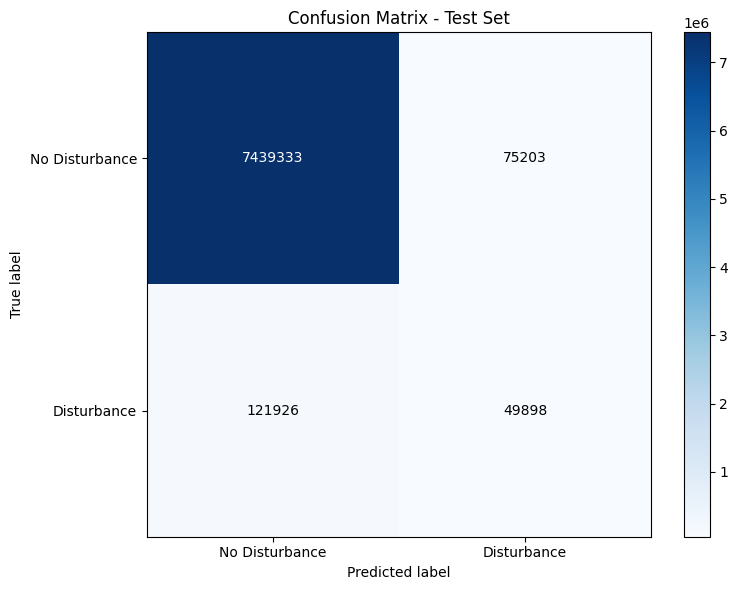

In [19]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['No Disturbance', 'Disturbance'],
       yticklabels=['No Disturbance', 'Disturbance'],
       title='Confusion Matrix - Test Set',
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import precision_recall_curve



print('='*80)

print('DYNAMIC THRESHOLD SELECTION (Validation PR Curve)')

print('='*80)



# Collect validation probabilities across years using saved scaler checkpoints

y_val_all = []

y_val_proba_all = []

for year_idx in range(1, n_years):

    year_val = year_values[year_idx]

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():

        with open(scaler_path, 'rb') as f:

            year_scaler = pickle.load(f)

    else:

        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)

    if year_scaler is None:

        continue

    X_val_year, y_val_year, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform',

    )

    if len(X_val_year) == 0:

        continue

    y_val_all.append(y_val_year)

    y_val_proba_all.append(model.predict_proba(X_val_year)[:, 1])



if len(y_val_all) == 0:

    raise ValueError('No validation samples available for threshold tuning.')



# Concatenate validation labels and probabilities

y_val_concat = np.concatenate(y_val_all)

y_val_proba_concat = np.concatenate(y_val_proba_all)



# Validation PR curve and AUPRC

val_pr_auc = average_precision_score(y_val_concat, y_val_proba_concat)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_concat, y_val_proba_concat)

f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)

best_idx = f1_vals.argmax()

best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5



print(f'Validation AUPRC: {val_pr_auc:.4f}')

print(f'Best threshold (max F1 on PR curve): {best_threshold:.4f}')

print(f'  Precision={precision_vals[best_idx]:.4f}, Recall={recall_vals[best_idx]:.4f}, F1={f1_vals[best_idx]:.4f}')



# Apply dynamic threshold to test set probabilities already computed

y_test_pred_dyn = (y_test_proba >= best_threshold).astype(int)

dyn_cm = confusion_matrix(y_test, y_test_pred_dyn)

tn, fp, fn, tp = dyn_cm.ravel()

dyn_fp_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan



# Test metrics with dynamic threshold

test_acc_dyn = accuracy_score(y_test, y_test_pred_dyn)

test_prec_dyn = precision_score(y_test, y_test_pred_dyn, zero_division=0)

test_rec_dyn = recall_score(y_test, y_test_pred_dyn, zero_division=0)

test_f1_dyn = f1_score(y_test, y_test_pred_dyn, zero_division=0)

test_pr_auc_dyn = average_precision_score(y_test, y_test_proba)



print('\n=== TEST SET WITH DYNAMIC THRESHOLD ===')

print(f'Threshold: {best_threshold:.4f}')

print(f'Accuracy:  {test_acc_dyn:.4f}')

print(f'Precision: {test_prec_dyn:.4f}')

print(f'Recall:    {test_rec_dyn:.4f}')

print(f'F1 Score:  {test_f1_dyn:.4f}')

print(f'False Positive Rate: {dyn_fp_rate:.4f}')

print('Confusion Matrix:')

print(dyn_cm)

DYNAMIC THRESHOLD SELECTION (Validation PR Curve)


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 2
  Dropped 1630 samples with NaN values (0.1%) for year 2


...

  Dropped 101 samples with invalid labels (class 255) for year 4
  Dropped 1707 samples with NaN values (0.1%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1697 samples with NaN values (0.1%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6
Validation AUPRC: 0.2620
Best threshold (max F1 on PR curve): 0.9731
  Precision=0.3870, Recall=0.2595, F1=0.3107

=== TEST SET WITH DYNAMIC THRESHOLD ===
Threshold: 0.9731
Accuracy:  0.9744
Precision: 0.3989
Recall:    0.2904
F1 Score:  0.3361
False Positive Rate: 0.0100
Confusion Matrix:
[[7439333   75203]
 [ 121926   49898]]


## 7. Save Model and Results

In [21]:
import pickle


# Save the trained model
model_path = Path('.') / f'sgd_classifier_model_prevyears_monthly_features_{OUTPUT_SUFFIX}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f'✓ Model saved to {model_path}')


# Save final incremental scaler (same state as latest year checkpoint)
if 'incremental_scaler' in globals() and hasattr(incremental_scaler, 'mean_'):
    final_scaler_path = models_dir / FINAL_SCALER_FILENAME
    with open(final_scaler_path, 'wb') as f:
        pickle.dump(incremental_scaler, f)
    print(f'✓ Final scaler saved to {final_scaler_path}')


# Per-year scaler checkpoints are already saved under models_dir
print(f'✓ Per-year scaler checkpoints saved under {models_dir} ({SCALER_FILE_TEMPLATE})')


# Legacy metrics files intentionally disabled in this notebook variant
print('✓ Legacy file exports disabled: history CSV and test-results JSON are no longer saved in Section 7.')
print('  Combined CSV/JSON exports are produced from Sections 14 and 15 in the combined export cell.')

✓ Model saved to sgd_classifier_model_prevyears_monthly_features_incremental_scaler.pkl
✓ Final scaler saved to models_prevyears_monthly_features_incremental_scaler\scaler_final_prevyears_monthly_features_incremental_scaler.pkl
✓ Per-year scaler checkpoints saved under models_prevyears_monthly_features_incremental_scaler (scaler_year_{year}_prevyears_monthly_features_incremental_scaler.pkl)
✓ Training history saved to sgd_classifier_history_prevyears_monthly_features_incremental_scaler.csv
✓ Test results saved to sgd_classifier_test_results_prevyears_monthly_features_incremental_scaler.json


## 8. Feature Importance Analysis


Top 15 Most Important Features:


,Feature,Coefficient,Abs_Coefficient
8,NDVI,-4.351851,4.351851
10,NDVI_last_year,3.192107,3.192107
9,NDWI,-3.093388,3.093388
16,NDVI_delta,-2.986720,2.986720
2,S2_B04,-2.281547,2.281547
13,S2_B03_last_year,2.019505,2.019505
20,log_years_since_last_disturbance,1.893440,1.893440
3,S2_B05,1.600980,1.600980
11,NDWI_last_year,-1.437939,1.437939
17,NDWI_delta,-1.255157,1.255157


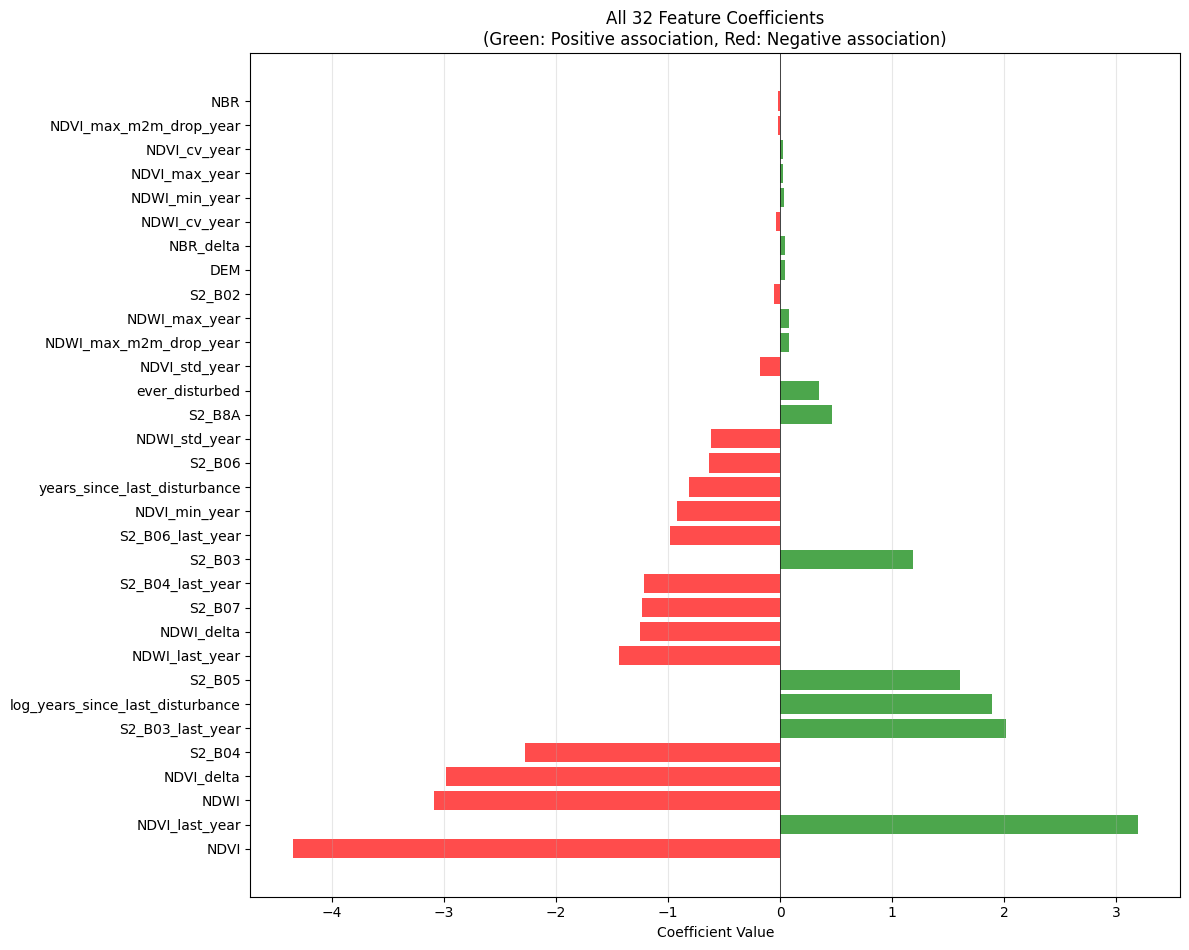

In [ ]:
# Shared utilities for dynamic thresholding across evaluation sections
from sklearn.metrics import precision_recall_curve


def _make_threshold_meta(source, reason, n_val_samples=0):
    return {
        'source': str(source),
        'reason': str(reason),
        'n_val_samples': int(n_val_samples),
    }


def _normalize_threshold_meta(
    meta,
    default_source='fallback_global',
    default_reason='best_threshold/default',
):
    if not isinstance(meta, dict):
        return _make_threshold_meta(default_source, default_reason, 0)

    return _make_threshold_meta(
        meta.get('source', default_source),
        meta.get('reason', default_reason),
        meta.get('n_val_samples', meta.get('n_val_threshold_samples', 0)),
    )


def _compute_best_f1_threshold(
    y_true,
    y_score,
    default_threshold=0.5,
    computed_source='computed_pr_f1',
    context_label='validation data',
):
    """Return PR-curve threshold that maximizes F1, with rich fallback metadata."""
    n_samples = int(len(y_true))

    if n_samples == 0:
        return float(default_threshold), _make_threshold_meta(
            'fallback_global',
            f'best_threshold/default: no samples available for {context_label}',
            0,
        )

    if len(np.unique(y_true)) <= 1:
        return float(default_threshold), _make_threshold_meta(
            'fallback_global',
            f'{context_label} labels contain one class only',
            n_samples,
        )

    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_score)
    f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
    best_idx = int(np.argmax(f1_vals))

    if best_idx < len(thresholds):
        return float(thresholds[best_idx]), _make_threshold_meta(
            computed_source,
            f'max F1 on {context_label} PR curve',
            n_samples,
        )

    return float(default_threshold), _make_threshold_meta(
        'fallback_global',
        f'PR argmax at terminal point without explicit threshold for {context_label}',
        n_samples,
    )


def _load_year_scaler(year_val):
    """Load scaler checkpoint for a year, with in-memory fallback."""
    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            return pickle.load(f)

    return globals().get('year_to_scaler_checkpoint', {}).get(year_val)


def _get_or_create_threshold_maps():
    """Ensure threshold maps exist and normalize year keys to int when possible."""
    pair_map_raw = globals().get('model_eval_year_thresholds')
    if not isinstance(pair_map_raw, dict):
        pair_map_raw = {}

    model_map_raw = globals().get('model_year_thresholds')
    if not isinstance(model_map_raw, dict):
        model_map_raw = {}

    pair_meta_raw = globals().get('model_eval_year_threshold_meta')
    if not isinstance(pair_meta_raw, dict):
        pair_meta_raw = {}

    model_meta_raw = globals().get('model_year_threshold_meta')
    if not isinstance(model_meta_raw, dict):
        model_meta_raw = {}

    normalized_pair = {}
    for mk, eval_map in pair_map_raw.items():
        try:
            mk_int = int(mk)
        except Exception:
            continue

        if not isinstance(eval_map, dict):
            continue

        normalized_pair[mk_int] = {}
        for ek, val in eval_map.items():
            try:
                ek_int = int(ek)
                normalized_pair[mk_int][ek_int] = float(val)
            except Exception:
                continue

    normalized_model = {}
    for mk, val in model_map_raw.items():
        try:
            normalized_model[int(mk)] = float(val)
        except Exception:
            continue

    normalized_pair_meta = {}
    for mk, eval_meta_map in pair_meta_raw.items():
        try:
            mk_int = int(mk)
        except Exception:
            continue

        if not isinstance(eval_meta_map, dict):
            continue

        normalized_pair_meta[mk_int] = {}
        for ek, meta in eval_meta_map.items():
            try:
                ek_int = int(ek)
            except Exception:
                continue
            normalized_pair_meta[mk_int][ek_int] = _normalize_threshold_meta(meta)

    normalized_model_meta = {}
    for mk, meta in model_meta_raw.items():
        try:
            mk_int = int(mk)
        except Exception:
            continue
        normalized_model_meta[mk_int] = _normalize_threshold_meta(meta)

    globals()['model_eval_year_thresholds'] = normalized_pair
    globals()['model_year_thresholds'] = normalized_model
    globals()['model_eval_year_threshold_meta'] = normalized_pair_meta
    globals()['model_year_threshold_meta'] = normalized_model_meta

    return normalized_pair, normalized_model, normalized_pair_meta, normalized_model_meta


def _compute_eval_year_threshold_for_model(year_model, eval_year_idx, eval_scaler, default_threshold=0.5):
    """Compute threshold for one model/eval-year pair from eval-year validation data."""
    eval_year_val = int(year_values[eval_year_idx])
    context_label = f'eval-year {eval_year_val} validation'

    if 'val_pixel_indices' not in globals():
        return float(default_threshold), _make_threshold_meta(
            'fallback_global',
            'best_threshold/default: validation indices unavailable',
            0,
        )

    X_val_year, y_val_year, _ = prepare_features_for_year(
        ds,
        val_pixel_indices,
        eval_year_idx,
        scaler=eval_scaler,
        scaler_mode='transform',
    )

    if len(X_val_year) == 0:
        return float(default_threshold), _make_threshold_meta(
            'fallback_global',
            f'no validation samples after preprocessing for eval-year {eval_year_val}',
            0,
        )

    y_val_proba = year_model.predict_proba(X_val_year)[:, 1]
    return _compute_best_f1_threshold(
        y_val_year,
        y_val_proba,
        default_threshold=default_threshold,
        computed_source='computed_pr_f1_eval_year',
        context_label=context_label,
    )


def resolve_dynamic_threshold(
    year_model,
    model_year_val,
    eval_year_val,
    eval_year_idx,
    eval_scaler,
    default_threshold=0.5,
    persist=True,
):
    """
    Resolve threshold with fallback order:
      1) pair-specific (model_year, eval_year)
      2) model-year threshold
      3) computed on eval-year validation (if possible)
      4) global fallback
    """
    pair_map, model_map, pair_meta_map, model_meta_map = _get_or_create_threshold_maps()

    model_key = int(model_year_val)
    eval_key = int(eval_year_val)

    if model_key in pair_map and eval_key in pair_map[model_key]:
        saved_meta = pair_meta_map.get(model_key, {}).get(
            eval_key,
            _make_threshold_meta('pair_specific_saved', 'persisted pair-specific threshold', 0),
        )
        return float(pair_map[model_key][eval_key]), _normalize_threshold_meta(saved_meta)

    if model_key in model_map:
        saved_meta = model_meta_map.get(
            model_key,
            _make_threshold_meta('model_year_saved', 'persisted model-year threshold', 0),
        )
        return float(model_map[model_key]), _normalize_threshold_meta(saved_meta)

    threshold, threshold_meta = _compute_eval_year_threshold_for_model(
        year_model,
        eval_year_idx,
        eval_scaler,
        default_threshold,
    )

    threshold_meta = _normalize_threshold_meta(threshold_meta)

    if persist:
        pair_map.setdefault(model_key, {})[eval_key] = float(threshold)
        pair_meta_map.setdefault(model_key, {})[eval_key] = threshold_meta.copy()
        if model_key == eval_key:
            model_map[model_key] = float(threshold)
            model_meta_map[model_key] = threshold_meta.copy()

    return float(threshold), threshold_meta


def get_global_dynamic_threshold(default_threshold=0.5, force_recompute=False):
    """Compute/reuse a global threshold from validation PR curve across years."""
    best_threshold_val = globals().get('best_threshold')
    best_threshold_meta = globals().get('best_threshold_meta')
    if not force_recompute and best_threshold_val is not None:
        cached_meta = _normalize_threshold_meta(
            best_threshold_meta,
            default_source='best_threshold_cached',
            default_reason='reused cached global threshold',
        )
        return float(best_threshold_val), cached_meta

    if 'model' not in globals():
        return float(default_threshold), _make_threshold_meta(
            'fallback_no_model',
            'global threshold unavailable because model is not defined',
            0,
        )

    if 'val_pixel_indices' not in globals():
        return float(default_threshold), _make_threshold_meta(
            'fallback_global',
            'best_threshold/default: validation indices unavailable',
            0,
        )

    y_val_all = []
    y_val_proba_all = []

    for year_idx in range(1, n_years):
        year_val = year_values[year_idx]
        year_scaler = _load_year_scaler(year_val)
        if year_scaler is None:
            continue

        X_val_year, y_val_year, _ = prepare_features_for_year(
            ds,
            val_pixel_indices,
            year_idx,
            scaler=year_scaler,
            scaler_mode='transform',
        )

        if len(X_val_year) == 0:
            continue

        y_val_all.append(y_val_year)
        y_val_proba_all.append(model.predict_proba(X_val_year)[:, 1])

    if len(y_val_all) == 0:
        return float(default_threshold), _make_threshold_meta(
            'fallback_global',
            'best_threshold/default: no validation data available across years',
            0,
        )

    y_val_concat = np.concatenate(y_val_all)
    y_val_proba_concat = np.concatenate(y_val_proba_all)
    threshold, threshold_meta = _compute_best_f1_threshold(
        y_val_concat,
        y_val_proba_concat,
        default_threshold=default_threshold,
        computed_source='global_computed_pr_f1',
        context_label='global validation data',
    )

    globals()['best_threshold'] = float(threshold)
    globals()['best_threshold_meta'] = threshold_meta.copy()
    return float(threshold), threshold_meta

## 9. Per-Year Model Evaluation on Test Sets

PER-YEAR MODEL EVALUATION ON TEST SETS


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1

Year 2017 (Test set: 1278700 samples):
  Threshold: 0.8677 (computed_pr_f1)
  Accuracy:  0.9556
  Precision: 0.1439
  Recall:    0.2928
  F1 Score:  0.1930
  ROC-AUC:   0.8464
  PR-AUC:    0.1126


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Year 2022 (Test set: 1282452 samples):
  Threshold: 0.9122 (computed_pr_f1)
  Accuracy:  0.9594
  Precision: 0.3825
  Recall:    0.4660
  F1 Score:  0.4201
  ROC-AUC:   0.8818
  PR-AUC:    0.4014

SUMMARY TABLE - PER-YEAR TEST RESULTS


,year,n_test_samples,threshold_used,threshold_source,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1278700,0.867670,computed_pr_f1,0.955606,0.143914,0.292783,0.192974,0.846385,0.112571
1,2018,1281398,0.918016,computed_pr_f1,0.976282,0.463767,0.371640,0.412624,0.892424,0.395498
2,2019,1281008,0.884057,computed_pr_f1,0.977824,0.454958,0.375109,0.411193,0.872227,0.359045
3,2020,1281489,0.906979,computed_pr_f1,0.976215,0.520084,0.377755,0.437638,0.894994,0.403619
4,2021,1281313,0.922475,computed_pr_f1,0.983650,0.524758,0.340772,0.413210,0.890653,0.391261
5,2022,1282452,0.912226,computed_pr_f1,0.959446,0.382512,0.465958,0.420131,0.881828,0.401422


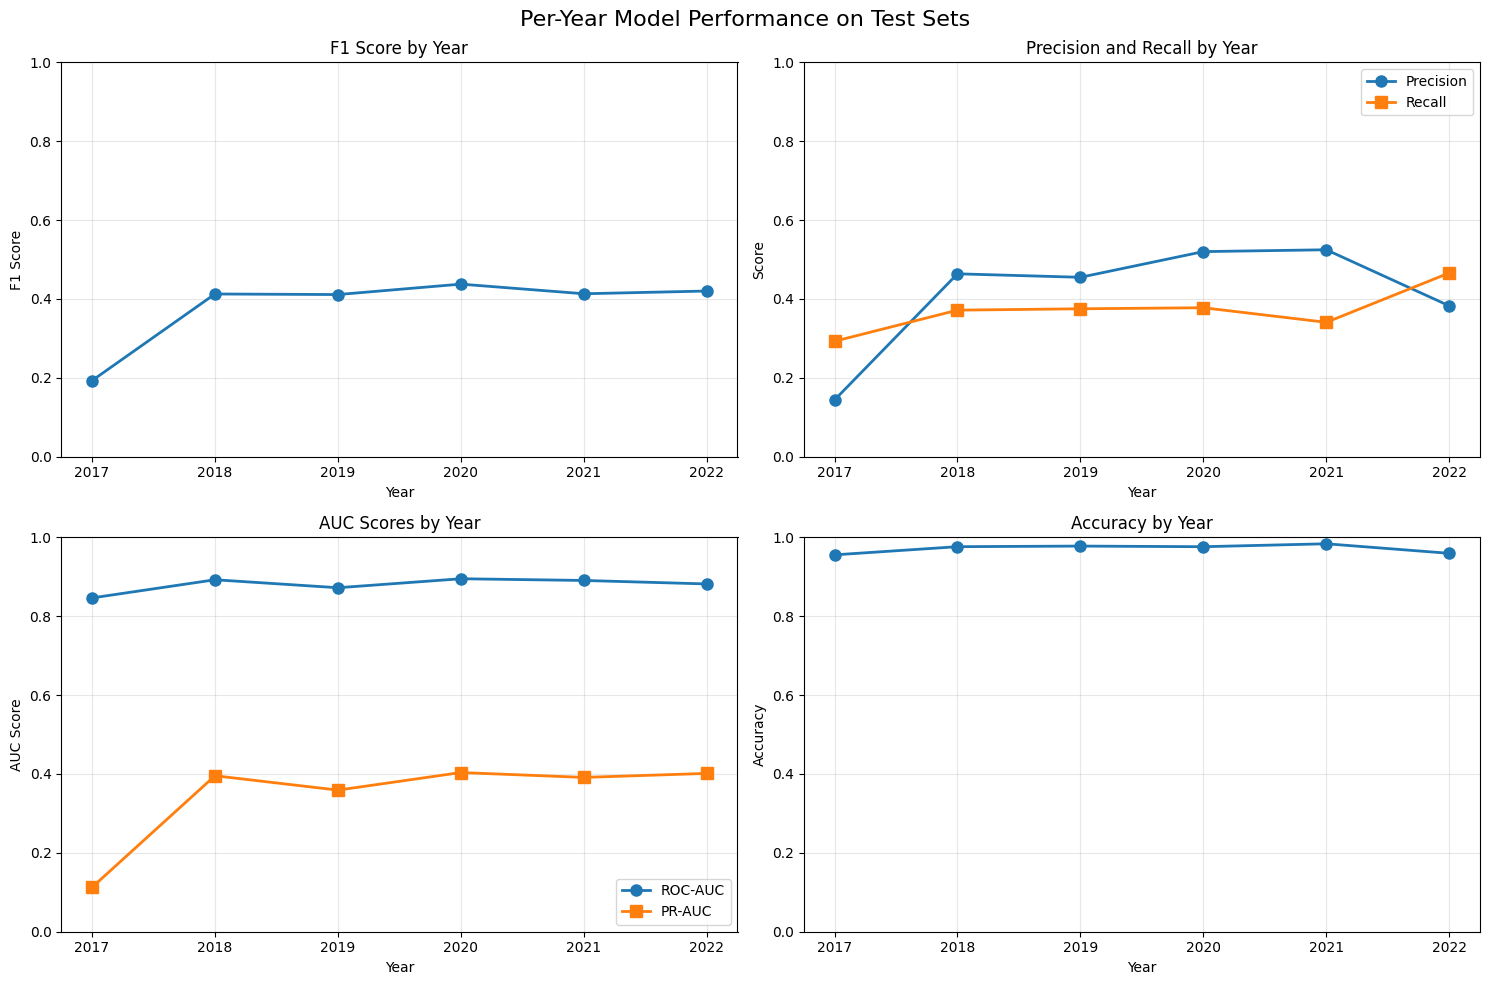

In [ ]:
# Evaluate each year's model on the test set for that year

print('='*80)
print('PER-YEAR MODEL EVALUATION ON TEST SETS')
print('='*80)


yearly_results = []
default_global_threshold = float(globals().get('best_threshold', 0.5))

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))
    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    # Load the model for this year
    if not year_model_path.exists():
        print(f'\nYear {year_val}: Model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)

    # Load the scaler checkpoint for this year
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)

    if year_scaler is None:
        print(f'\nYear {year_val}: Scaler file not found, skipping...')
        continue

    # Resolve dynamic threshold for this model-year on same eval year
    decision_threshold, threshold_meta = resolve_dynamic_threshold(
        year_model=year_model,
        model_year_val=year_val,
        eval_year_val=year_val,
        eval_year_idx=year_idx,
        eval_scaler=year_scaler,
        default_threshold=default_global_threshold,
        persist=True,
    )
    threshold_source = threshold_meta['source']
    threshold_reason = threshold_meta['reason']
    n_val_threshold_samples = int(threshold_meta['n_val_samples'])

    # Get test data for this year using its scaler checkpoint
    X_test_year, y_test_year, _ = prepare_features_for_year(
        ds,
        test_pixel_indices,
        year_idx,
        scaler=year_scaler,
        scaler_mode='transform',
    )

    if len(X_test_year) == 0:
        print(f'\nYear {year_val}: No test samples available, skipping...')
        continue

    # Make predictions
    y_proba_year = year_model.predict_proba(X_test_year)[:, 1]
    y_pred_year = (y_proba_year >= decision_threshold).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test_year, y_pred_year)
    prec = precision_score(y_test_year, y_pred_year, zero_division=0)
    rec = recall_score(y_test_year, y_pred_year, zero_division=0)
    f1 = f1_score(y_test_year, y_pred_year, zero_division=0)

    if len(np.unique(y_test_year)) > 1:
        roc_auc = roc_auc_score(y_test_year, y_proba_year)
        pr_auc = average_precision_score(y_test_year, y_proba_year)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # Store results
    yearly_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_year),
        'scaler_year_used': int(year_val),
        'threshold_used': float(decision_threshold),
        'threshold_source': threshold_source,
        'threshold_reason': threshold_reason,
        'n_val_threshold_samples': n_val_threshold_samples,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    })

    # Print results
    print(f'\nYear {year_val} (Test set: {len(X_test_year)} samples):')
    print(f'  Threshold: {decision_threshold:.4f} ({threshold_source})')
    print(f'  Reason:    {threshold_reason}')
    print(f'  Val size:  {n_val_threshold_samples}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

# Create DataFrame of yearly results
yearly_results_df = pd.DataFrame(yearly_results)

print('\n' + '='*80)
print('SUMMARY TABLE - PER-YEAR TEST RESULTS')
print('='*80)
display(yearly_results_df)

# Plot per-year performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Per-Year Model Performance on Test Sets', fontsize=16)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(yearly_results_df['year'], yearly_results_df['f1_score'], marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score by Year')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(yearly_results_df['year'], yearly_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)
ax.plot(yearly_results_df['year'], yearly_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall by Year')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 3: AUC Scores
ax = axes[1, 0]
ax.plot(yearly_results_df['year'], yearly_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)
ax.plot(yearly_results_df['year'], yearly_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores by Year')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 4: Accuracy
ax = axes[1, 1]
ax.plot(yearly_results_df['year'], yearly_results_df['accuracy'], marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Year')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 10. Positive Rate Analysis by Split and Year

POSITIVE RATE ANALYSIS BY SPLIT AND YEAR


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 21401 samples with NaN values (0.4%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Year 2022:
  Train: 3.06% (171390/5592080 samples)
  Val:   2.88% (36686/1272609 samples)
  Test:  3.15% (40435/1282452 samples)

SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR


,year,train_positive_rate,val_positive_rate,test_positive_rate
0,2017,0.018464,0.018813,0.018129
1,2018,0.020541,0.022138,0.022416
2,2019,0.020253,0.018279,0.020642
3,2020,0.018629,0.016918,0.024500
4,2021,0.015222,0.015573,0.016893
5,2022,0.030649,0.028827,0.031529


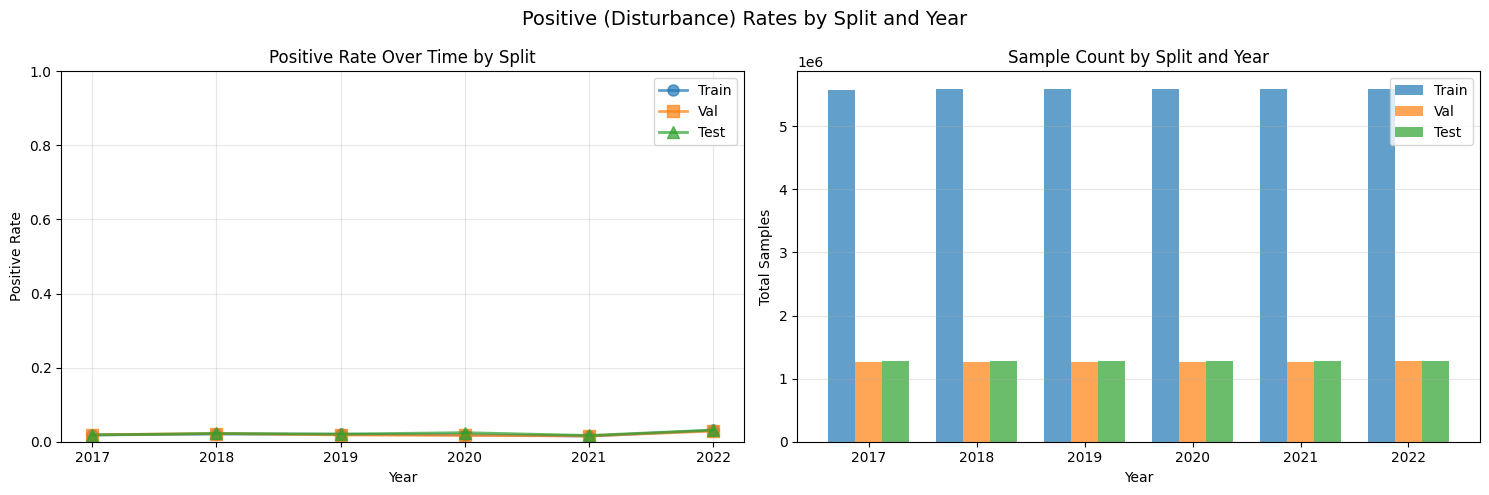


STATISTICS - POSITIVE RATES

Train Positive Rate:
count    6.000000
mean     0.020626
std      0.005263
min      0.015222
25%      0.018505
50%      0.019441
75%      0.020469
max      0.030649
Name: train_positive_rate, dtype: float64

Val Positive Rate:
count    6.000000
mean     0.020091
std      0.004815
min      0.015573
25%      0.017259
50%      0.018546
75%      0.021307
max      0.028827
Name: val_positive_rate, dtype: float64

Test Positive Rate:
count    6.000000
mean     0.022351
std      0.005280
min      0.016893
25%      0.018757
50%      0.021529
75%      0.023979
max      0.031529
Name: test_positive_rate, dtype: float64


In [24]:
# Calculate positive (disturbance) rates for each split by year

print('='*80)

print('POSITIVE RATE ANALYSIS BY SPLIT AND YEAR')

print('='*80)



split_positive_rates = []



for year_idx in range(1, n_years):

    year_val = year_values[year_idx]



    # Load year-specific scaler checkpoint (not strictly needed for labels, but keeps preprocessing consistent)

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():

        with open(scaler_path, 'rb') as f:

            year_scaler = pickle.load(f)

    else:

        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)



    if year_scaler is None:

        print(f'\nYear {year_val}: scaler checkpoint missing, skipping...')

        continue



    # Get labels for each split using the year scaler checkpoint

    X_train_year, y_train_year, _ = prepare_features_for_year(

        ds,

        train_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform',

    )

    X_val_year, y_val_year, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform',

    )

    X_test_year, y_test_year, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform',

    )



    # Skip if no data

    if len(y_train_year) == 0 or len(y_val_year) == 0 or len(y_test_year) == 0:

        print(f'\nYear {year_val}: Skipped (missing data in one or more splits)')

        continue



    # Calculate positive rates

    train_pos_rate = (y_train_year == 1).sum() / len(y_train_year)

    val_pos_rate = (y_val_year == 1).sum() / len(y_val_year)

    test_pos_rate = (y_test_year == 1).sum() / len(y_test_year)



    # Store results

    split_positive_rates.append({

        'year': year_val,

        'train_positive_rate': train_pos_rate,

        'train_total_samples': len(y_train_year),

        'train_positive_count': (y_train_year == 1).sum(),

        'val_positive_rate': val_pos_rate,

        'val_total_samples': len(y_val_year),

        'val_positive_count': (y_val_year == 1).sum(),

        'test_positive_rate': test_pos_rate,

        'test_total_samples': len(y_test_year),

        'test_positive_count': (y_test_year == 1).sum()

    })



    # Print results

    print(f'\nYear {year_val}:')

    print(f'  Train: {train_pos_rate:.2%} ({(y_train_year == 1).sum()}/{len(y_train_year)} samples)')

    print(f'  Val:   {val_pos_rate:.2%} ({(y_val_year == 1).sum()}/{len(y_val_year)} samples)')

    print(f'  Test:  {test_pos_rate:.2%} ({(y_test_year == 1).sum()}/{len(y_test_year)} samples)')



# Create DataFrame of positive rates

positive_rates_df = pd.DataFrame(split_positive_rates)



print('\n' + '='*80)

print('SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR')

print('='*80)

display(positive_rates_df[['year', 'train_positive_rate', 'val_positive_rate', 'test_positive_rate']])



# Plot positive rates by split

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle('Positive (Disturbance) Rates by Split and Year', fontsize=14)



# Plot 1: Positive rates by year

ax = axes[0]

ax.plot(positive_rates_df['year'], positive_rates_df['train_positive_rate'], 

        label='Train', marker='o', linewidth=2, markersize=8, alpha=0.7)

ax.plot(positive_rates_df['year'], positive_rates_df['val_positive_rate'], 

        label='Val', marker='s', linewidth=2, markersize=8, alpha=0.7)

ax.plot(positive_rates_df['year'], positive_rates_df['test_positive_rate'], 

        label='Test', marker='^', linewidth=2, markersize=8, alpha=0.7)

ax.set_xlabel('Year')

ax.set_ylabel('Positive Rate')

ax.set_title('Positive Rate Over Time by Split')

ax.legend()

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 2: Sample counts by split

ax = axes[1]

x_pos = np.arange(len(positive_rates_df))

width = 0.25

ax.bar(x_pos - width, positive_rates_df['train_total_samples'], width, label='Train', alpha=0.7)

ax.bar(x_pos, positive_rates_df['val_total_samples'], width, label='Val', alpha=0.7)

ax.bar(x_pos + width, positive_rates_df['test_total_samples'], width, label='Test', alpha=0.7)

ax.set_xlabel('Year')

ax.set_ylabel('Total Samples')

ax.set_title('Sample Count by Split and Year')

ax.set_xticks(x_pos)

ax.set_xticklabels([int(y) for y in positive_rates_df['year']])

ax.legend()

ax.grid(True, alpha=0.3, axis='y')



plt.tight_layout()

plt.show()



# Summary statistics

print('\n' + '='*80)

print('STATISTICS - POSITIVE RATES')

print('='*80)

print('\nTrain Positive Rate:')

print(positive_rates_df['train_positive_rate'].describe())

print('\nVal Positive Rate:')

print(positive_rates_df['val_positive_rate'].describe())

print('\nTest Positive Rate:')

print(positive_rates_df['test_positive_rate'].describe())

## 11.Final Model evaluation on each year's test set

In [ ]:
# Evaluate the final trained model on each year's test set (summary table)

print('='*80)
print('FINAL MODEL EVALUATION ON EACH YEAR\'S TEST SET')
print('='*80)


default_global_threshold = float(globals().get('best_threshold', 0.5))
print(f'Global fallback threshold: {default_global_threshold:.4f}\n')

final_model_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)

    if year_scaler is None:
        print(f'Year {year_val}: Scaler not found, skipping...')
        continue

    # Dynamic threshold for final model evaluated on this specific year
    decision_threshold, threshold_meta = _compute_eval_year_threshold_for_model(
        year_model=model,
        eval_year_idx=year_idx,
        eval_scaler=year_scaler,
        default_threshold=default_global_threshold,
    )
    threshold_source = threshold_meta['source']
    threshold_reason = threshold_meta['reason']
    n_val_threshold_samples = int(threshold_meta['n_val_samples'])

    X_test_year, y_test_year, _ = prepare_features_for_year(
        ds,
        test_pixel_indices,
        year_idx,
        scaler=year_scaler,
        scaler_mode='transform',
    )
    if len(X_test_year) == 0:
        continue

    y_proba = model.predict_proba(X_test_year)[:, 1]
    y_pred = (y_proba >= decision_threshold).astype(int)

    acc = accuracy_score(y_test_year, y_pred)
    prec = precision_score(y_test_year, y_pred, zero_division=0)
    rec = recall_score(y_test_year, y_pred, zero_division=0)
    f1 = f1_score(y_test_year, y_pred, zero_division=0)

    if len(np.unique(y_test_year)) > 1:
        roc_auc = roc_auc_score(y_test_year, y_proba)
        pr_auc = average_precision_score(y_test_year, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    final_model_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_year),
        'scaler_year_used': int(year_val),
        'threshold_used': float(decision_threshold),
        'threshold_source': threshold_source,
        'threshold_reason': threshold_reason,
        'n_val_threshold_samples': n_val_threshold_samples,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    })

    print(f'Year {year_val}: threshold={decision_threshold:.4f} ({threshold_source}), F1={f1:.4f}')

final_model_results_df = pd.DataFrame(final_model_results)

print('\n' + '='*80)
print('SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS')
print('='*80)
display(final_model_results_df)

FINAL MODEL EVALUATION ON EACH YEAR'S TEST SET
Global fallback threshold: 0.9731



C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS


,year,n_test_samples,threshold_used,threshold_source,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1278700,0.780465,computed_pr_f1,0.948131,0.114235,0.275571,0.161515,0.825282,0.084060
1,2018,1281398,0.959324,computed_pr_f1,0.967164,0.302380,0.355626,0.326849,0.869379,0.314962
2,2019,1281008,0.987268,computed_pr_f1,0.978323,0.465856,0.341830,0.394320,0.864503,0.346065
3,2020,1281489,0.971888,computed_pr_f1,0.976296,0.524200,0.351860,0.421079,0.886351,0.393040
4,2021,1281313,0.961259,computed_pr_f1,0.981729,0.448537,0.355556,0.396670,0.890470,0.368113
5,2022,1282452,0.912226,computed_pr_f1,0.959446,0.382512,0.465958,0.420131,0.881828,0.401422


## 12. Cumulative Test Set Evaluation

CUMULATIVE TEST SET EVALUATION
Global fallback threshold: 0.9731



C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1

Year 2017 model on cumulative test set (2017-2017):
  Test samples: 1,278,700
  Threshold: 0.8677 (pair_specific_saved)
  Accuracy:  0.9556
  Precision: 0.1439
  Recall:    0.2928
  F1 Score:  0.1930
  ROC-AUC:   0.8464
  PR-AUC:    0.1126


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Year 2022 model on cumulative test set (2017-2022):
  Test samples: 7,686,360
  Threshold: 0.9122 (pair_specific_saved)
  Accuracy:  0.9436
  Precision: 0.1928
  Recall:    0.4786
  F1 Score:  0.2749
  ROC-AUC:   0.8329
  PR-AUC:    0.2983

SUMMARY TABLE - CUMULATIVE TEST SET RESULTS


,year,n_test_samples,years_included,threshold_used,threshold_source,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1278700,2017-2017,0.867670,pair_specific_saved,0.955606,0.143914,0.292783,0.192974,0.846385,0.112571
1,2018,2560098,2017-2018,0.918016,pair_specific_saved,0.975721,0.360671,0.255621,0.299193,0.807818,0.246012
2,2019,3841106,2017-2019,0.884057,pair_specific_saved,0.974328,0.335797,0.264423,0.295866,0.799962,0.222467
3,2020,5122595,2017-2020,0.906979,pair_specific_saved,0.970162,0.308619,0.316673,0.312594,0.811657,0.240669
4,2021,6403908,2017-2021,0.922475,pair_specific_saved,0.973970,0.349050,0.310680,0.328749,0.801320,0.262284
5,2022,7686360,2017-2022,0.912226,pair_specific_saved,0.943552,0.192813,0.478647,0.274891,0.832894,0.298299


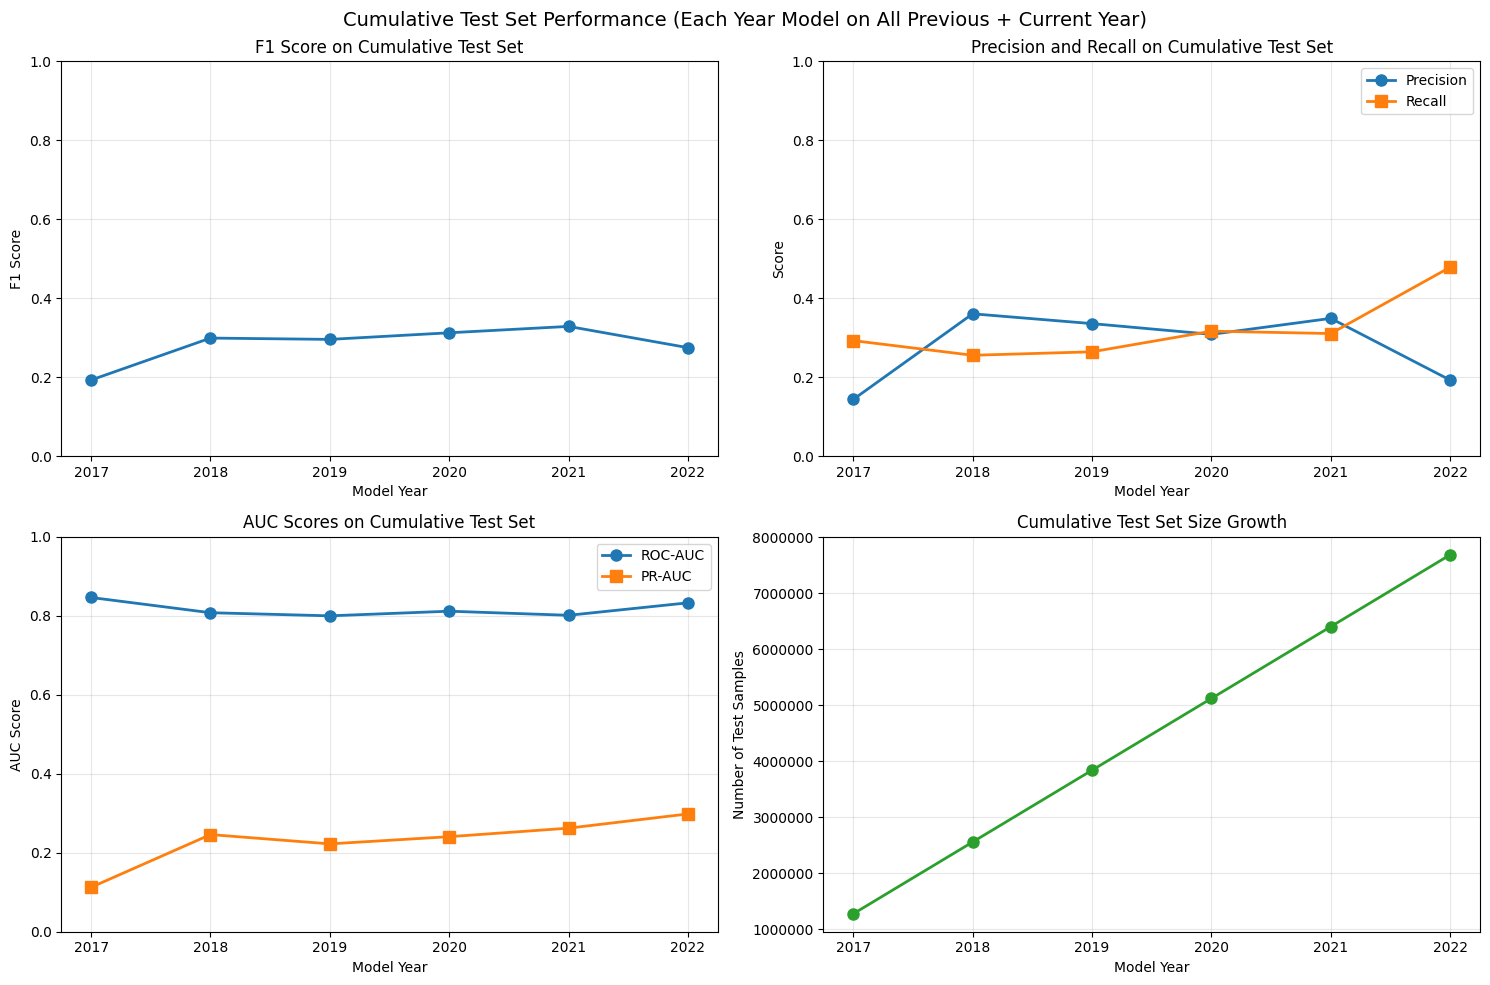

In [ ]:
# Evaluate each year's model on cumulative test sets (that year + all previous years)

print('='*80)
print('CUMULATIVE TEST SET EVALUATION')
print('='*80)


default_global_threshold = float(globals().get('best_threshold', 0.5))
print(f'Global fallback threshold: {default_global_threshold:.4f}\n')

cumulative_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    # Load the model for this year
    if not year_model_path.exists():
        print(f'\nYear {year_val}: Model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)

    # Resolve threshold for this model year in own-year context
    model_year_scaler = _load_year_scaler(year_val)
    if model_year_scaler is None:
        print(f'\nYear {year_val}: model-year scaler missing, skipping...')
        continue

    decision_threshold, threshold_meta = resolve_dynamic_threshold(
        year_model=year_model,
        model_year_val=year_val,
        eval_year_val=year_val,
        eval_year_idx=year_idx,
        eval_scaler=model_year_scaler,
        default_threshold=default_global_threshold,
        persist=True,
    )
    threshold_source = threshold_meta['source']
    threshold_reason = threshold_meta['reason']
    n_val_threshold_samples = int(threshold_meta['n_val_samples'])

    # Accumulate test data from year 1 up to current year,
    # each transformed with its own eval-year scaler
    X_cumulative = []
    y_cumulative = []

    for past_year_idx in range(1, year_idx + 1):
        past_year_val = year_values[past_year_idx]
        past_year_scaler = _load_year_scaler(past_year_val)

        if past_year_scaler is None:
            print(f'  Year {year_val}: missing scaler for eval year {past_year_val}, skipping that year.')
            continue

        X_test_year, y_test_year, _ = prepare_features_for_year(
            ds,
            test_pixel_indices,
            past_year_idx,
            scaler=past_year_scaler,
            scaler_mode='transform',
        )
        if len(X_test_year) > 0:
            X_cumulative.append(X_test_year)
            y_cumulative.append(y_test_year)

    # Skip if no cumulative data
    if len(X_cumulative) == 0:
        print(f'\nYear {year_val}: No cumulative test data available, skipping...')
        continue

    # Combine all accumulated test data
    X_test_cumulative = np.vstack(X_cumulative)
    y_test_cumulative = np.concatenate(y_cumulative)

    # Make predictions
    y_proba_cumulative = year_model.predict_proba(X_test_cumulative)[:, 1]
    y_pred_cumulative = (y_proba_cumulative >= decision_threshold).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test_cumulative, y_pred_cumulative)
    prec = precision_score(y_test_cumulative, y_pred_cumulative, zero_division=0)
    rec = recall_score(y_test_cumulative, y_pred_cumulative, zero_division=0)
    f1 = f1_score(y_test_cumulative, y_pred_cumulative, zero_division=0)

    if len(np.unique(y_test_cumulative)) > 1:
        roc_auc = roc_auc_score(y_test_cumulative, y_proba_cumulative)
        pr_auc = average_precision_score(y_test_cumulative, y_proba_cumulative)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # Store results
    cumulative_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_cumulative),
        'years_included': f'2017-{int(year_val)}',
        'threshold_used': float(decision_threshold),
        'threshold_source': threshold_source,
        'threshold_reason': threshold_reason,
        'n_val_threshold_samples': n_val_threshold_samples,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    })

    # Print results
    print(f'\nYear {year_val} model on cumulative test set (2017-{int(year_val)}):')
    print(f'  Test samples: {len(X_test_cumulative):,}')
    print(f'  Threshold: {decision_threshold:.4f} ({threshold_source})')
    print(f'  Reason:    {threshold_reason}')
    print(f'  Val size:  {n_val_threshold_samples}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

# Create DataFrame of cumulative results
cumulative_results_df = pd.DataFrame(cumulative_results)

print('\n' + '='*80)
print('SUMMARY TABLE - CUMULATIVE TEST SET RESULTS')
print('='*80)
display(cumulative_results_df)

# Plot cumulative performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Cumulative Test Set Performance (Each Year Model on All Previous + Current Year)', fontsize=14)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(cumulative_results_df['year'], cumulative_results_df['f1_score'], marker='o', linewidth=2, markersize=8, color='tab:blue')
ax.set_xlabel('Model Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score on Cumulative Test Set')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(cumulative_results_df['year'], cumulative_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)
ax.plot(cumulative_results_df['year'], cumulative_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Model Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall on Cumulative Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 3: AUC Scores
ax = axes[1, 0]
ax.plot(cumulative_results_df['year'], cumulative_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)
ax.plot(cumulative_results_df['year'], cumulative_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Model Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores on Cumulative Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 4: Sample size growth
ax = axes[1, 1]
ax.plot(cumulative_results_df['year'], cumulative_results_df['n_test_samples'], marker='o', linewidth=2, markersize=8, color='tab:green')
ax.set_xlabel('Model Year')
ax.set_ylabel('Number of Test Samples')
ax.set_title('Cumulative Test Set Size Growth')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## 13. Next-Year Model Evaluation
Evaluate each year model on the next year's test set (year t -> year t+1)

In [ ]:
# Evaluate each year's model on the next year's test set (year t -> year t+1)

print('='*80)
print('NEXT-YEAR MODEL EVALUATION (Year t model on Year t+1 test set)')
print('='*80)


default_global_threshold = float(globals().get('best_threshold', 0.5))
print(f'Global fallback threshold: {default_global_threshold:.4f}\n')

next_year_results = []

for year_idx in range(1, n_years - 1):
    year_val = year_values[year_idx]
    next_year_val = year_values[year_idx + 1]
    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    # Load the model for this year
    if not year_model_path.exists():
        print(f'\nYear {year_val}: Model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)

    # Load eval-year scaler (next year), with fallback to model-year scaler if unavailable
    eval_scaler = _load_year_scaler(next_year_val)
    eval_scaler_source = 'next_year_scaler'
    scaler_year_used = int(next_year_val)
    if eval_scaler is None:
        eval_scaler = _load_year_scaler(year_val)
        eval_scaler_source = 'model_year_scaler_fallback'
        scaler_year_used = int(year_val)

    if eval_scaler is None:
        print(f'\nYear {year_val}: no scaler available for next-year evaluation, skipping...')
        continue

    # Resolve dynamic threshold for this model on next-year context
    decision_threshold, threshold_meta = resolve_dynamic_threshold(
        year_model=year_model,
        model_year_val=year_val,
        eval_year_val=next_year_val,
        eval_year_idx=year_idx + 1,
        eval_scaler=eval_scaler,
        default_threshold=default_global_threshold,
        persist=True,
    )
    threshold_source = threshold_meta['source']
    threshold_reason = threshold_meta['reason']
    n_val_threshold_samples = int(threshold_meta['n_val_samples'])

    # Get test data for the next year
    X_test_next, y_test_next, _ = prepare_features_for_year(
        ds,
        test_pixel_indices,
        year_idx + 1,
        scaler=eval_scaler,
        scaler_mode='transform',
    )

    if len(X_test_next) == 0:
        print(f'\nYear {year_val} -> {next_year_val}: No test samples available, skipping...')
        continue

    # Make predictions
    y_proba_next = year_model.predict_proba(X_test_next)[:, 1]
    y_pred_next = (y_proba_next >= decision_threshold).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test_next, y_pred_next)
    prec = precision_score(y_test_next, y_pred_next, zero_division=0)
    rec = recall_score(y_test_next, y_pred_next, zero_division=0)
    f1 = f1_score(y_test_next, y_pred_next, zero_division=0)

    if len(np.unique(y_test_next)) > 1:
        roc_auc = roc_auc_score(y_test_next, y_proba_next)
        pr_auc = average_precision_score(y_test_next, y_proba_next)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # Store results (year refers to model year)
    next_year_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_next),
        'scaler_year_used': scaler_year_used,
        'scaler_source': eval_scaler_source,
        'threshold_used': float(decision_threshold),
        'threshold_source': threshold_source,
        'threshold_reason': threshold_reason,
        'n_val_threshold_samples': n_val_threshold_samples,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    })

    # Print results
    print(f'\nModel year {year_val} -> Test year {next_year_val} (Test set: {len(X_test_next)} samples):')
    print(f'  Threshold: {decision_threshold:.4f} ({threshold_source})')
    print(f'  Reason:    {threshold_reason}')
    print(f'  Val size:  {n_val_threshold_samples}')
    print(f'  Scaler:    {eval_scaler_source}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

# Create DataFrame of next-year results
next_year_results_df = pd.DataFrame(next_year_results)

print('\n' + '='*80)
print('SUMMARY TABLE - NEXT-YEAR TEST RESULTS')
print('='*80)
display(next_year_results_df)

NEXT-YEAR MODEL EVALUATION (Year t model on Year t+1 test set)
Global fallback threshold: 0.9731



C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2303 samples with NaN values (0.2%) for year 2

Model year 2017 -> Test year 2018 (Test set: 1281398 samples):
  Threshold: 0.8677 (model_year_saved)
  Scaler:    next_year_scaler
  Accuracy:  0.9647
  Precision: 0.2384
  Recall:    0.2629
  F1 Score:  0.2501
  ROC-AUC:   0.8525
  PR-AUC:    0.1995


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 3
  Dropped 2693 samples with NaN values (0.2%) for year 3

Model year 2018 -> Test year 2019 (Test set: 1281008 samples):
  Threshold: 0.9180 (model_year_saved)
  Scaler:    next_year_scaler
  Accuracy:  0.9797
  Precision: 0.5337
  Recall:    0.1306
  F1 Score:  0.2099
  ROC-AUC:   0.8369
  PR-AUC:    0.2094


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5

Model year 2020 -> Test year 2021 (Test set: 1281313 samples):
  Threshold: 0.9070 (model_year_saved)
  Scaler:    next_year_scaler
  Accuracy:  0.9822
  Precision: 0.4619
  Recall:    0.3191
  F1 Score:  0.3774
  ROC-AUC:   0.8842
  PR-AUC:    0.3493


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Model year 2021 -> Test year 2022 (Test set: 1282452 samples):
  Threshold: 0.9225 (model_year_saved)
  Scaler:    next_year_scaler
  Accuracy:  0.9713
  Precision: 0.6055
  Recall:    0.2565
  F1 Score:  0.3603
  ROC-AUC:   0.8713
  PR-AUC:    0.3834

SUMMARY TABLE - NEXT-YEAR TEST RESULTS


,year,n_test_samples,scaler_used,threshold_used,threshold_source,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281398,next_year_scaler,0.867670,model_year_saved,0.964655,0.238435,0.262881,0.250062,0.852549,0.199473
1,2018,1281008,next_year_scaler,0.918016,model_year_saved,0.979698,0.533684,0.130621,0.209874,0.836851,0.209428
2,2019,1281489,next_year_scaler,0.884057,model_year_saved,0.977926,0.589581,0.325870,0.419742,0.873581,0.394328
3,2020,1281313,next_year_scaler,0.906979,model_year_saved,0.982219,0.461940,0.319058,0.377429,0.884216,0.349295
4,2021,1282452,next_year_scaler,0.922475,model_year_saved,0.971289,0.605500,0.256486,0.360336,0.871251,0.383401


## 14. Side-by-Side Comparison of All Evaluation Approaches

In [ ]:
# Compare all four evaluation approaches with separate tables
print('='*80)
print('EVALUATION RESULTS: FOUR SEPARATE APPROACHES')
print('='*80)

comparison_columns = [
    'year',
    'threshold_used',
    'threshold_source',
    'threshold_reason',
    'n_val_threshold_samples',
    'scaler_year_used',
    'scaler_source',
    'accuracy',
    'precision',
    'recall',
    'f1_score',
    'roc_auc',
    'pr_auc',
    'n_test_samples',
    'years_included',
]

# Table 1: Final Model on each year
print('\n' + '='*80)
print('TABLE 1: Final Model (trained on all years) evaluated on each year')
print('='*80)
table1 = final_model_results_df[[col for col in comparison_columns if col in final_model_results_df.columns]].copy()
display(table1)

# Table 2: Year-specific Model on that year
print('\n' + '='*80)
print('TABLE 2: Year-Specific Model evaluated on that year only')
print('='*80)
table2 = yearly_results_df[[col for col in comparison_columns if col in yearly_results_df.columns]].copy()
display(table2)

# Table 3: Year-specific Model on cumulative test set
print('\n' + '='*80)
print('TABLE 3: Year-Specific Model evaluated on cumulative test set (all years up to that year)')
print('='*80)
table3 = cumulative_results_df[[col for col in comparison_columns if col in cumulative_results_df.columns]].copy()
display(table3)

# Table 4: Year-specific Model on next year's test set
print('\n' + '='*80)
print('TABLE 4: Year-Specific Model evaluated on next year\'s test set (year t -> year t+1)')
print('='*80)
table4 = next_year_results_df[[col for col in comparison_columns if col in next_year_results_df.columns]].copy()
display(table4)

print('\nThreshold policy summary:')
print('- Section 6: global dynamic threshold from validation PR curve (best_threshold).')
print('- Sections 9, 12, 13: eval-year-aware thresholds with persisted model/eval-year metadata.')
print('- Section 11: per-eval-year dynamic threshold for the final model.')

EVALUATION RESULTS: FOUR SEPARATE APPROACHES

TABLE 1: Final Model (trained on all years) evaluated on each year


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.948131,0.114235,0.275571,0.161515,0.825282,0.084060,1278700
1,2018,0.967164,0.302380,0.355626,0.326849,0.869379,0.314962,1281398
2,2019,0.978323,0.465856,0.341830,0.394320,0.864503,0.346065,1281008
3,2020,0.976296,0.524200,0.351860,0.421079,0.886351,0.393040,1281489
4,2021,0.981729,0.448537,0.355556,0.396670,0.890470,0.368113,1281313
5,2022,0.959446,0.382512,0.465958,0.420131,0.881828,0.401422,1282452



TABLE 2: Year-Specific Model evaluated on that year only


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.955606,0.143914,0.292783,0.192974,0.846385,0.112571,1278700
1,2018,0.976282,0.463767,0.371640,0.412624,0.892424,0.395498,1281398
2,2019,0.977824,0.454958,0.375109,0.411193,0.872227,0.359045,1281008
3,2020,0.976215,0.520084,0.377755,0.437638,0.894994,0.403619,1281489
4,2021,0.983650,0.524758,0.340772,0.413210,0.890653,0.391261,1281313
5,2022,0.959446,0.382512,0.465958,0.420131,0.881828,0.401422,1282452



TABLE 3: Year-Specific Model evaluated on cumulative test set (all years up to that year)


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.955606,0.143914,0.292783,0.192974,0.846385,0.112571,1278700
1,2018,0.975721,0.360671,0.255621,0.299193,0.807818,0.246012,2560098
2,2019,0.974328,0.335797,0.264423,0.295866,0.799962,0.222467,3841106
3,2020,0.970162,0.308619,0.316673,0.312594,0.811657,0.240669,5122595
4,2021,0.973970,0.349050,0.310680,0.328749,0.801320,0.262284,6403908
5,2022,0.943552,0.192813,0.478647,0.274891,0.832894,0.298299,7686360



TABLE 4: Year-Specific Model evaluated on next year's test set (year t -> year t+1)


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.964655,0.238435,0.262881,0.250062,0.852549,0.199473,1281398
1,2018,0.979698,0.533684,0.130621,0.209874,0.836851,0.209428,1281008
2,2019,0.977926,0.589581,0.325870,0.419742,0.873581,0.394328,1281489
3,2020,0.982219,0.461940,0.319058,0.377429,0.884216,0.349295,1281313
4,2021,0.971289,0.605500,0.256486,0.360336,0.871251,0.383401,1282452



Threshold policy summary:
- Section 6: global dynamic threshold from validation PR curve (best_threshold).
- Sections 9, 12, 13: dynamic thresholds with fallback order pair-specific -> model-year -> global.
- Section 11: per-eval-year dynamic threshold for the final model.


## 15. Standalone Prior-Years Evaluation by Model
Evaluate each model year on all prior years including its own year, computed locally in this section only.

In [29]:
# Standalone evaluation: each model year on all prior years (including current year)

import pickle

from pathlib import Path

import numpy as np

import pandas as pd

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score,

    precision_recall_curve,

)



# Required objects from early notebook setup (data load + feature function)

required_globals = {

    "ds": "Run Section 1 (Load Prepared Data and Split) first.",

    "test_pixel_indices": "Run Section 1 (Load Prepared Data and Split) first.",

    "prepare_features_for_year": "Run Section 2 (Feature Engineering) first.",

}

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:

    missing_help = "\n".join([f"- {name}: {required_globals[name]}" for name in missing_globals])

    raise RuntimeError(

        "Missing required notebook objects for standalone prior-years evaluation:\n"

        f"{missing_help}"

    )



# Keep directory and naming conventions aligned with incremental-scaler settings

output_suffix_local = globals().get("OUTPUT_SUFFIX", "incremental_scaler")

default_models_dir = Path(".") / f"models_prevyears_monthly_features_{output_suffix_local}"

models_dir_local = Path(globals().get("models_dir", default_models_dir))



model_file_template_local = globals().get(

    "MODEL_FILE_TEMPLATE",

    f"model_year_{{year}}_prevyears_monthly_features_{output_suffix_local}.pkl",

)

scaler_file_template_local = globals().get(

    "SCALER_FILE_TEMPLATE",

    f"scaler_year_{{year}}_prevyears_monthly_features_{output_suffix_local}.pkl",

)



if not models_dir_local.exists():

    raise FileNotFoundError(

        f"Model directory not found: {models_dir_local.resolve()}\n"

        "Train and save yearly models/scalers before running this section."

    )



n_years_local = len(ds.year)

year_values_local = ds.year.values

result_columns = [

    "year",

    "accuracy",

    "precision",

    "recall",

    "f1_score",

    "roc_auc",

    "pr_auc",

    "n_test_samples",

    "scaler_year_used",

    "threshold_used",

    "threshold_source",

    "threshold_reason",

    "n_val_threshold_samples",

]



print(f"Using models directory: {models_dir_local.resolve()}")

print(f"Model filename template: {model_file_template_local}")

print(f"Scaler filename template: {scaler_file_template_local}")



# Global fallback threshold used only when an eval-year threshold cannot be computed

global_fallback_threshold = float(globals().get("best_threshold", 0.5))

if "best_threshold" in globals():

    print(f"Global fallback threshold (best_threshold): {global_fallback_threshold:.4f}")

else:

    print(f"No best_threshold found. Using default fallback threshold: {global_fallback_threshold:.4f}")



has_val_indices = "val_pixel_indices" in globals()

if not has_val_indices:

    print(

        "Warning: val_pixel_indices not found. Eval-year threshold tuning is disabled; "

        "fallback threshold will be used."

    )



# Stores only tables computed by this section

standalone_prior_year_tables = {}



# Backward-compatible outputs used by later sections

model_year_thresholds = {}

model_year_threshold_meta = {}



# New detailed threshold outputs (model year -> eval year -> threshold/meta)

model_eval_year_thresholds = {}

model_eval_year_threshold_meta = {}



# Cache scalers to avoid repeated disk reads within this section

scaler_cache = {}





def load_scaler_for_year(year_val):

    """Load scaler for a specific calendar year with optional in-memory fallback."""

    year_key = int(year_val)

    if year_key in scaler_cache:

        return scaler_cache[year_key]



    scaler_path_year = models_dir_local / scaler_file_template_local.format(year=year_key)

    scaler_obj = None



    if scaler_path_year.exists():

        with open(scaler_path_year, "rb") as f:

            scaler_obj = pickle.load(f)

    else:

        # Fallback for in-session training where files may not be persisted yet.

        in_memory_scalers = globals().get("year_to_scaler_checkpoint", {})

        if not in_memory_scalers:

            in_memory_scalers = globals().get("year_to_scaler", {})



        if year_key in in_memory_scalers:

            scaler_obj = in_memory_scalers[year_key]

        elif year_val in in_memory_scalers:

            scaler_obj = in_memory_scalers[year_val]



    if scaler_obj is not None:

        scaler_cache[year_key] = scaler_obj



    return scaler_obj





def compute_eval_year_threshold(year_model, eval_year_idx, eval_year_scaler):

    """Tune threshold for one model-year/eval-year pair on eval-year validation data."""

    threshold_local = global_fallback_threshold

    threshold_source = "fallback_global"

    threshold_reason = "best_threshold/default"

    n_val_threshold_samples = 0



    if not has_val_indices:

        return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples



    X_val_year, y_val_year, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        eval_year_idx,

        scaler=eval_year_scaler,

        scaler_mode='transform',

    )



    if len(X_val_year) == 0:

        threshold_reason = "no validation samples after preprocessing"

        return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples



    n_val_threshold_samples = int(len(y_val_year))

    y_val_proba = year_model.predict_proba(X_val_year)[:, 1]



    if len(np.unique(y_val_year)) > 1:

        precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_year, y_val_proba)

        f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)

        best_idx = int(np.argmax(f1_vals))



        if best_idx < len(thresholds):

            threshold_local = float(thresholds[best_idx])

            threshold_source = "computed_pr_f1_eval_year"

            threshold_reason = (

                f"max F1 on eval-year {int(year_values_local[eval_year_idx])} validation PR curve"

            )

        else:

            threshold_reason = "PR argmax at terminal point without explicit threshold"

    else:

        threshold_reason = "validation labels contain one class only"



    return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples





print("=" * 80)

print("STANDALONE PRIOR-YEARS EVALUATION BY MODEL YEAR")

print("=" * 80)



for model_year_idx in range(1, n_years_local):

    model_year_val = year_values_local[model_year_idx]

    model_year_key = int(model_year_val)

    model_path = models_dir_local / model_file_template_local.format(year=model_year_key)



    if not model_path.exists():

        print(f"\nModel year {model_year_key}: model file not found, skipping.")

        continue



    with open(model_path, "rb") as f:

        year_model = pickle.load(f)



    model_eval_year_thresholds[model_year_key] = {}

    model_eval_year_threshold_meta[model_year_key] = {}

    model_year_rows = []



    print(

        f"\nModel year {model_year_key}: evaluating years <= {model_year_key} "

        "using each eval year's scaler."

    )



    for eval_year_idx in range(1, model_year_idx + 1):

        eval_year_val = year_values_local[eval_year_idx]

        eval_year_key = int(eval_year_val)



        # Core policy requested: use the evaluated year's scaler.

        eval_year_scaler = load_scaler_for_year(eval_year_val)

        if eval_year_scaler is None:

            print(

                f"  Model {model_year_key} -> Eval {eval_year_key}: "

                "eval-year scaler not found, skipped."

            )

            continue



        (

            threshold_local,

            threshold_source,

            threshold_reason,

            n_val_threshold_samples,

        ) = compute_eval_year_threshold(year_model, eval_year_idx, eval_year_scaler)



        model_eval_year_thresholds[model_year_key][eval_year_key] = threshold_local

        model_eval_year_threshold_meta[model_year_key][eval_year_key] = {

            "source": threshold_source,

            "reason": threshold_reason,

            "n_val_samples": int(n_val_threshold_samples),

        }



        X_eval, y_eval, _ = prepare_features_for_year(

            ds,

            test_pixel_indices,

            eval_year_idx,

            scaler=eval_year_scaler,

            scaler_mode='transform',

        )



        if len(X_eval) == 0:

            print(

                f"  Model {model_year_key} -> Eval {eval_year_key}: "

                "no samples after preprocessing, skipped."

            )

            continue



        y_proba = year_model.predict_proba(X_eval)[:, 1]

        y_pred = (y_proba >= threshold_local).astype(int)



        acc = accuracy_score(y_eval, y_pred)

        prec = precision_score(y_eval, y_pred, zero_division=0)

        rec = recall_score(y_eval, y_pred, zero_division=0)

        f1 = f1_score(y_eval, y_pred, zero_division=0)



        if len(np.unique(y_eval)) > 1:

            roc_auc = roc_auc_score(y_eval, y_proba)

            pr_auc = average_precision_score(y_eval, y_proba)

        else:

            roc_auc = np.nan

            pr_auc = np.nan



        model_year_rows.append(

            {

                "year": eval_year_val,

                "accuracy": acc,

                "precision": prec,

                "recall": rec,

                "f1_score": f1,

                "roc_auc": roc_auc,

                "pr_auc": pr_auc,

                "n_test_samples": len(X_eval),

                "scaler_year_used": eval_year_key,

                "threshold_used": threshold_local,

                "threshold_source": threshold_source,

                "threshold_reason": threshold_reason,

                "n_val_threshold_samples": int(n_val_threshold_samples),

            }

        )



        print(

            f"  Model {model_year_key} -> Eval {eval_year_key}: "

            f"threshold={threshold_local:.4f} ({threshold_source}), F1={f1:.4f}"

        )



    if not model_year_rows:

        print(f"\nModel year {model_year_key}: no evaluable prior-year data, table not created.")

        continue



    # Backward compatibility for downstream diagnostic cells:

    # keep one threshold per model year (use model-on-own-year threshold when available).

    own_year_threshold = model_eval_year_thresholds[model_year_key].get(model_year_key)

    own_year_meta = model_eval_year_threshold_meta[model_year_key].get(model_year_key)



    if own_year_threshold is not None and own_year_meta is not None:

        model_year_thresholds[model_year_key] = own_year_threshold

        model_year_threshold_meta[model_year_key] = own_year_meta.copy()

    else:

        model_year_thresholds[model_year_key] = global_fallback_threshold

        model_year_threshold_meta[model_year_key] = {

            "source": "fallback_global",

            "reason": "own-year threshold unavailable",

            "n_val_samples": 0,

        }



    model_year_df = pd.DataFrame(model_year_rows)

    ordered_columns = [col for col in result_columns if col in model_year_df.columns]

    model_year_df = model_year_df[ordered_columns].copy()

    standalone_prior_year_tables[model_year_key] = model_year_df



    print("\n" + "=" * 80)

    print(f"MODEL YEAR {model_year_key} -> EVALUATED ON YEARS <= {model_year_key}")

    print("=" * 80)

    display(model_year_df)



if not standalone_prior_year_tables:

    print("\nNo standalone prior-years tables were produced.")

else:

    print(f"\nGenerated {len(standalone_prior_year_tables)} standalone prior-years tables.")

    print("Per-model/eval-year thresholds are available in model_eval_year_thresholds.")

    print("Backward-compatible per-model thresholds are available in model_year_thresholds.")

Using models directory: C:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features_incremental_scaler
Model filename template: model_year_{year}_prevyears_monthly_features_incremental_scaler.pkl
Scaler filename template: scaler_year_{year}_prevyears_monthly_features_incremental_scaler.pkl
Global fallback threshold (best_threshold): 0.9731
STANDALONE PRIOR-YEARS EVALUATION BY MODEL YEAR

Model year 2017: evaluating years <= 2017 using each eval year's scaler.


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1
  Model 2017 -> Eval 2017: threshold=0.8677 (computed_pr_f1_eval_year), F1=0.1930

MODEL YEAR 2017 -> EVALUATED ON YEARS <= 2017


...

  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6
  Model 2022 -> Eval 2022: threshold=0.9122 (computed_pr_f1_eval_year), F1=0.4201

MODEL YEAR 2022 -> EVALUATED ON YEARS <= 2022


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,scaler_year_used,threshold_used,threshold_source,threshold_reason,n_val_threshold_samples
0,2017,0.948131,0.114235,0.275571,0.161515,0.825282,0.084060,1278700,2017,0.780465,computed_pr_f1_eval_year,max F1 on eval-year 2017 validation PR curve,1270825
1,2018,0.967164,0.302380,0.355626,0.326849,0.869379,0.314962,1281398,2018,0.959324,computed_pr_f1_eval_year,max F1 on eval-year 2018 validation PR curve,1271706
2,2019,0.978323,0.465856,0.341830,0.394320,0.864503,0.346065,1281008,2019,0.987268,computed_pr_f1_eval_year,max F1 on eval-year 2019 validation PR curve,1271570
3,2020,0.976296,0.524200,0.351860,0.421079,0.886351,0.393040,1281489,2020,0.971888,computed_pr_f1_eval_year,max F1 on eval-year 2020 validation PR curve,1271629
4,2021,0.981729,0.448537,0.355556,0.396670,0.890470,0.368113,1281313,2021,0.961259,computed_pr_f1_eval_year,max F1 on eval-year 2021 validation PR curve,1271639
5,2022,0.959446,0.382512,0.465958,0.420131,0.881828,0.401422,1282452,2022,0.912226,computed_pr_f1_eval_year,max F1 on eval-year 2022 validation PR curve,1272609



Generated 6 standalone prior-years tables.
Per-model/eval-year thresholds are available in model_eval_year_thresholds.
Backward-compatible per-model thresholds are available in model_year_thresholds.


In [32]:
# Combined export from Section 14 and Section 15 (tidy + source-first schema)
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

required_exports = [
    'table1',
    'table2',
    'table3',
    'table4',
    'standalone_prior_year_tables',
    'model_eval_year_thresholds',
    'model_eval_year_threshold_meta',
    'model_year_thresholds',
]

missing_exports = [name for name in required_exports if name not in globals()]
if missing_exports:
    raise RuntimeError(
        'Missing required variables for combined export. Run Sections 14 and 15 first. Missing: '
        + ', '.join(missing_exports)
    )


def _to_native(value):
    if isinstance(value, dict):
        return {str(k): _to_native(v) for k, v in value.items()}
    if isinstance(value, list):
        return [_to_native(v) for v in value]
    if isinstance(value, tuple):
        return [_to_native(v) for v in value]
    if isinstance(value, np.ndarray):
        return [_to_native(v) for v in value.tolist()]
    if isinstance(value, np.generic):
        return value.item()
    if pd.isna(value):
        return None
    return value


def _safe_get(row, key, default=np.nan):
    return row[key] if key in row.index else default


source_catalog = {
    'final_model_per_year': {
        'source_label': 'Final model per year',
        'source_section': '14',
        'evaluation_scope': 'final_model_on_each_test_year',
    },
    'year_model_same_year': {
        'source_label': 'Year model on same year',
        'source_section': '14',
        'evaluation_scope': 'year_model_on_its_own_year',
    },
    'year_model_cumulative': {
        'source_label': 'Year model on cumulative years',
        'source_section': '14',
        'evaluation_scope': 'year_model_on_2017_to_current_year',
    },
    'year_model_next_year': {
        'source_label': 'Year model on next year',
        'source_section': '14',
        'evaluation_scope': 'year_model_on_next_year',
    },
    'standalone_prior_years': {
        'source_label': 'Standalone prior-years',
        'source_section': '15',
        'evaluation_scope': 'year_model_on_all_prior_years_local',
    },
}

section14_sources = {
    'final_model_per_year': table1.copy(),
    'year_model_same_year': table2.copy(),
    'year_model_cumulative': table3.copy(),
    'year_model_next_year': table4.copy(),
}

records = []

for source_id, df in section14_sources.items():
    if df is None or df.empty:
        continue

    source_meta = source_catalog[source_id]

    for _, row in df.iterrows():
        year_value = _safe_get(row, 'year')
        model_year = np.nan
        eval_year = np.nan
        years_included = _safe_get(row, 'years_included')

        if source_id == 'final_model_per_year':
            model_year = 'final_all_years'
            eval_year = year_value
        elif source_id == 'year_model_same_year':
            model_year = year_value
            eval_year = year_value
        elif source_id == 'year_model_cumulative':
            model_year = year_value
            eval_year = np.nan
            if pd.isna(years_included) and not pd.isna(year_value):
                years_included = f'2017-{int(year_value)}'
        elif source_id == 'year_model_next_year':
            model_year = year_value
            eval_year = year_value + 1 if not pd.isna(year_value) else np.nan

        record = {
            'source_id': source_id,
            'source_label': source_meta['source_label'],
            'source_section': source_meta['source_section'],
            'evaluation_scope': source_meta['evaluation_scope'],
            'row_uid': f"{source_id}:{_to_native(model_year)}:{_to_native(eval_year)}",
            'model_year': model_year,
            'eval_year': eval_year,
            'year': year_value,
            'years_included': years_included,
            'scaler_year_used': _safe_get(row, 'scaler_year_used'),
            'threshold_used': _safe_get(row, 'threshold_used'),
            'threshold_source': _safe_get(row, 'threshold_source'),
            'threshold_reason': _safe_get(row, 'threshold_reason'),
            'n_val_threshold_samples': _safe_get(row, 'n_val_threshold_samples'),
            'n_test_samples': _safe_get(row, 'n_test_samples'),
            'accuracy': _safe_get(row, 'accuracy'),
            'precision': _safe_get(row, 'precision'),
            'recall': _safe_get(row, 'recall'),
            'f1_score': _safe_get(row, 'f1_score'),
            'roc_auc': _safe_get(row, 'roc_auc'),
            'pr_auc': _safe_get(row, 'pr_auc'),
        }
        records.append(record)

for model_year_key, model_year_df in standalone_prior_year_tables.items():
    if model_year_df is None or model_year_df.empty:
        continue

    source_id = 'standalone_prior_years'
    source_meta = source_catalog[source_id]

    for _, row in model_year_df.iterrows():
        model_year = _safe_get(row, 'model_year', model_year_key)
        eval_year = _safe_get(row, 'eval_year', _safe_get(row, 'year'))

        record = {
            'source_id': source_id,
            'source_label': source_meta['source_label'],
            'source_section': source_meta['source_section'],
            'evaluation_scope': source_meta['evaluation_scope'],
            'row_uid': f"{source_id}:{_to_native(model_year)}:{_to_native(eval_year)}",
            'model_year': model_year,
            'eval_year': eval_year,
            'year': _safe_get(row, 'year'),
            'years_included': _safe_get(row, 'years_included'),
            'scaler_year_used': _safe_get(row, 'scaler_year_used'),
            'threshold_used': _safe_get(row, 'threshold_used'),
            'threshold_source': _safe_get(row, 'threshold_source'),
            'threshold_reason': _safe_get(row, 'threshold_reason'),
            'n_val_threshold_samples': _safe_get(row, 'n_val_threshold_samples'),
            'n_test_samples': _safe_get(row, 'n_test_samples'),
            'accuracy': _safe_get(row, 'accuracy'),
            'precision': _safe_get(row, 'precision'),
            'recall': _safe_get(row, 'recall'),
            'f1_score': _safe_get(row, 'f1_score'),
            'roc_auc': _safe_get(row, 'roc_auc'),
            'pr_auc': _safe_get(row, 'pr_auc'),
        }
        records.append(record)

if not records:
    raise RuntimeError('No rows available for combined export. Ensure Sections 14 and 15 produced results.')

combined_results_df = pd.DataFrame(records)

canonical_columns = [
    'source_id',
    'source_label',
    'source_section',
    'evaluation_scope',
    'row_uid',
    'model_year',
    'eval_year',
    'year',
    'years_included',
    'scaler_year_used',
    'threshold_used',
    'threshold_source',
    'threshold_reason',
    'n_val_threshold_samples',
    'n_test_samples',
    'accuracy',
    'precision',
    'recall',
    'f1_score',
    'roc_auc',
    'pr_auc',
]

for col in canonical_columns:
    if col not in combined_results_df.columns:
        combined_results_df[col] = np.nan

combined_results_df = combined_results_df[canonical_columns].copy()

output_suffix = globals().get('OUTPUT_SUFFIX', 'incremental_scaler')
combined_csv_path = Path('.') / f'sgd_classifier_combined_results_prevyears_monthly_features_{output_suffix}.csv'
combined_json_path = Path('.') / f'sgd_classifier_combined_results_prevyears_monthly_features_{output_suffix}.json'

combined_results_df.to_csv(combined_csv_path, index=False)

schema = [
    {'name': 'source_id', 'description': 'Stable technical source identifier'},
    {'name': 'source_label', 'description': 'Human-readable source label'},
    {'name': 'source_section', 'description': 'Notebook section where result is produced'},
    {'name': 'evaluation_scope', 'description': 'Evaluation setup summary'},
    {'name': 'row_uid', 'description': 'Unique row key: source_id:model_year:eval_year'},
    {'name': 'model_year', 'description': 'Model year key or final_all_years'},
    {'name': 'eval_year', 'description': 'Evaluation year when applicable'},
    {'name': 'year', 'description': 'Original year field from source table'},
    {'name': 'years_included', 'description': 'Year span used for cumulative evaluation'},
    {'name': 'scaler_year_used', 'description': 'Scaler year used for transformation (if applicable)'},
    {'name': 'threshold_used', 'description': 'Decision threshold value'},
    {'name': 'threshold_source', 'description': 'How threshold was selected'},
    {'name': 'threshold_reason', 'description': 'Additional threshold context'},
    {'name': 'n_val_threshold_samples', 'description': 'Validation sample count used for threshold search'},
    {'name': 'n_test_samples', 'description': 'Number of test samples'},
    {'name': 'accuracy', 'description': 'Accuracy metric'},
    {'name': 'precision', 'description': 'Precision metric'},
    {'name': 'recall', 'description': 'Recall metric'},
    {'name': 'f1_score', 'description': 'F1-score metric'},
    {'name': 'roc_auc', 'description': 'ROC-AUC metric'},
    {'name': 'pr_auc', 'description': 'PR-AUC metric'},
]

json_payload = {
    'metadata': {
        'generated_at_utc': datetime.now(timezone.utc).isoformat(),
        'output_suffix': output_suffix,
        'legacy_exports_disabled': True,
        'sections_included': [14, 15],
        'row_count': int(len(combined_results_df)),
    },
    'schema': schema,
    'source_catalog': _to_native(source_catalog),
    'threshold_maps': {
        'model_eval_year_thresholds': _to_native(model_eval_year_thresholds),
        'model_eval_year_threshold_meta': _to_native(model_eval_year_threshold_meta),
        'model_year_thresholds': _to_native(model_year_thresholds),
    },
    'rows': _to_native(combined_results_df.to_dict(orient='records')),
}

with open(combined_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_payload, f, indent=2)

source_counts = combined_results_df.groupby(['source_id', 'source_label']).size().reset_index(name='rows')
print(f'✓ Combined results CSV saved to {combined_csv_path}')
print(f'✓ Combined results JSON saved to {combined_json_path}')
print(f'✓ Exported {len(combined_results_df):,} total rows with tidy source-first schema.')
print('\nRows by source:')
display(source_counts)
print('✓ Legacy file exports remain disabled: history CSV and test-results JSON are not produced.')

✓ Combined results CSV saved to sgd_classifier_combined_results_prevyears_monthly_features_incremental_scaler.csv
✓ Combined results JSON saved to sgd_classifier_combined_results_prevyears_monthly_features_incremental_scaler.json
✓ Exported 44 total rows with tidy source-first schema.

Rows by source:


,source_id,source_label,rows
0,final_model_per_year,Final model per year,6
1,standalone_prior_years,Standalone prior-years,21
2,year_model_cumulative,Year model on cumulative years,6
3,year_model_next_year,Year model on next year,5
4,year_model_same_year,Year model on same year,6


✓ Legacy file exports remain disabled: history CSV and test-results JSON are not produced.


In [30]:
# Diagnostic: why some later model years can get F1=0 on year 2017

import pickle

from pathlib import Path

import numpy as np

import pandas as pd

from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    average_precision_score,

    precision_recall_curve,

    accuracy_score,

    roc_auc_score,

)



required_objects = {

    "ds": "Run Cell 4 (load dataset/splits) first.",

    "test_pixel_indices": "Run Cell 4 (load dataset/splits) first.",

    "prepare_features_for_year": "Run Cell 6 (feature engineering) first.",

}

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:

    msg = "\n".join([f"- {name}: {required_objects[name]}" for name in missing_objects])

    raise RuntimeError(f"Missing required objects:\n{msg}")



output_suffix_diag = globals().get("OUTPUT_SUFFIX", "incremental_scaler")

default_models_dir_diag = Path(".") / f"models_prevyears_monthly_features_{output_suffix_diag}"

models_dir_diag = Path(globals().get("models_dir", default_models_dir_diag))

model_file_template_diag = globals().get(

    "MODEL_FILE_TEMPLATE",

    f"model_year_{{year}}_prevyears_monthly_features_{output_suffix_diag}.pkl",

)

scaler_file_template_diag = globals().get(

    "SCALER_FILE_TEMPLATE",

    f"scaler_year_{{year}}_prevyears_monthly_features_{output_suffix_diag}.pkl",

)

if not models_dir_diag.exists():

    raise FileNotFoundError(f"Model directory not found: {models_dir_diag.resolve()}")



year_values_diag = ds.year.values

if len(year_values_diag) < 2:

    raise RuntimeError("Dataset does not contain evaluable years (year index 1 is missing).")



eval_year_idx = 1

eval_year_val = int(year_values_diag[eval_year_idx])

global_default_threshold = float(globals().get("best_threshold", 0.5))

saved_model_thresholds = globals().get("model_year_thresholds", {})



print("=" * 100)

print(f"DIAGNOSTIC: MODEL-YEAR BEHAVIOR ON EVAL YEAR {eval_year_val}")

print("=" * 100)

print(f"Models directory: {models_dir_diag.resolve()}")

print(f"Global fallback threshold: {global_default_threshold:.4f}")



# Optional probe: compare with eval-year scaler (2017 scaler) to detect scaling mismatch effects.

eval_year_scaler = None

eval_year_scaler_path = models_dir_diag / scaler_file_template_diag.format(year=eval_year_val)

if eval_year_scaler_path.exists():

    with open(eval_year_scaler_path, "rb") as f:

        eval_year_scaler = pickle.load(f)



diagnostic_rows = []



# Focus on model years after 2017 because this is where F1=0 was observed.

for model_year_idx in range(2, len(year_values_diag)):

    model_year_val = int(year_values_diag[model_year_idx])

    model_path = models_dir_diag / model_file_template_diag.format(year=model_year_val)

    scaler_path = models_dir_diag / scaler_file_template_diag.format(year=model_year_val)



    if not model_path.exists() or not scaler_path.exists():

        print(f"Model year {model_year_val}: missing model/scaler file, skipped.")

        continue



    with open(model_path, "rb") as f:

        year_model = pickle.load(f)

    with open(scaler_path, "rb") as f:

        model_year_scaler = pickle.load(f)



    if model_year_val in saved_model_thresholds:

        threshold_local = float(saved_model_thresholds[model_year_val])

        threshold_source = "model_year_thresholds"

    else:

        threshold_local = global_default_threshold

        threshold_source = "global_fallback"



    # Evaluate year 2017 using the model-year scaler (same setup as standalone prior-years section).

    X_eval, y_eval, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        eval_year_idx,

        scaler=model_year_scaler,

        scaler_mode='transform',

    )



    if len(X_eval) == 0:

        print(f"Model year {model_year_val}: no evaluable samples for year {eval_year_val}.")

        continue



    y_proba = year_model.predict_proba(X_eval)[:, 1]

    y_pred = (y_proba >= threshold_local).astype(np.uint8)



    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()



    precision = precision_score(y_eval, y_pred, zero_division=0)

    recall = recall_score(y_eval, y_pred, zero_division=0)

    f1 = f1_score(y_eval, y_pred, zero_division=0)

    acc = accuracy_score(y_eval, y_pred)



    if len(np.unique(y_eval)) > 1:

        roc_auc = roc_auc_score(y_eval, y_proba)

        pr_auc = average_precision_score(y_eval, y_proba)

    else:

        roc_auc = np.nan

        pr_auc = np.nan



    p_vals, r_vals, pr_thresholds = precision_recall_curve(y_eval, y_proba)

    f1_curve = 2.0 * (p_vals * r_vals) / (p_vals + r_vals + 1e-12)

    best_idx = int(np.argmax(f1_curve))

    oracle_best_f1 = float(f1_curve[best_idx])

    oracle_best_threshold = float(pr_thresholds[best_idx]) if best_idx < len(pr_thresholds) else np.nan



    # Optional: evaluate the same model on 2017 using 2017 scaler to quantify scaling effect.

    f1_with_2017_scaler = np.nan

    pred_pos_rate_with_2017_scaler = np.nan

    if eval_year_scaler is not None:

        X_eval_2017_scaler, y_eval_2017_scaler, _ = prepare_features_for_year(

            ds,

            test_pixel_indices,

            eval_year_idx,

            scaler=eval_year_scaler,

            scaler_mode='transform',

        )

        if len(X_eval_2017_scaler) > 0 and len(X_eval_2017_scaler) == len(X_eval):

            y_proba_2017_scaler = year_model.predict_proba(X_eval_2017_scaler)[:, 1]

            y_pred_2017_scaler = (y_proba_2017_scaler >= threshold_local).astype(np.uint8)

            f1_with_2017_scaler = f1_score(y_eval_2017_scaler, y_pred_2017_scaler, zero_division=0)

            pred_pos_rate_with_2017_scaler = float((y_pred_2017_scaler == 1).mean())



    q50, q90, q95, q99 = np.quantile(y_proba, [0.50, 0.90, 0.95, 0.99])

    label_pos_rate = float((y_eval == 1).mean())

    pred_pos_rate = float((y_pred == 1).mean())



    diagnostic_rows.append(

        {

            "model_year": model_year_val,

            "threshold": threshold_local,

            "threshold_source": threshold_source,

            "n_eval_samples_2017": int(len(y_eval)),

            "label_pos_rate_2017": label_pos_rate,

            "pred_pos_rate_2017": pred_pos_rate,

            "accuracy_2017": float(acc),

            "precision_2017": float(precision),

            "recall_2017": float(recall),

            "f1_2017": float(f1),

            "roc_auc_2017": float(roc_auc) if not np.isnan(roc_auc) else np.nan,

            "pr_auc_2017": float(pr_auc) if not np.isnan(pr_auc) else np.nan,

            "tp_2017": int(tp),

            "fp_2017": int(fp),

            "fn_2017": int(fn),

            "tn_2017": int(tn),

            "proba_q50": float(q50),

            "proba_q90": float(q90),

            "proba_q95": float(q95),

            "proba_q99": float(q99),

            "oracle_best_f1_2017": oracle_best_f1,

            "oracle_best_threshold_2017": oracle_best_threshold,

            "f1_2017_with_2017_scaler": float(f1_with_2017_scaler) if not np.isnan(f1_with_2017_scaler) else np.nan,

            "pred_pos_rate_2017_with_2017_scaler": (

                float(pred_pos_rate_with_2017_scaler)

                if not np.isnan(pred_pos_rate_with_2017_scaler)

                else np.nan

            ),

        }

    )



if not diagnostic_rows:

    print("No diagnostic rows were produced.")

else:

    diagnostic_df = pd.DataFrame(diagnostic_rows).sort_values("model_year").reset_index(drop=True)

    display(diagnostic_df)



    print("\n" + "-" * 100)

    print("ROWS WITH F1_2017 == 0")

    print("-" * 100)

    zero_f1_df = diagnostic_df[diagnostic_df["f1_2017"] == 0].copy()

    if zero_f1_df.empty:

        print("No zero-F1 rows on 2017 were found for model years after 2017 in this run.")

    else:

        display(

            zero_f1_df[

                [

                    "model_year",

                    "threshold",

                    "label_pos_rate_2017",

                    "pred_pos_rate_2017",

                    "tp_2017",

                    "fn_2017",

                    "proba_q95",

                    "proba_q99",

                    "oracle_best_f1_2017",

                    "oracle_best_threshold_2017",

                    "f1_2017_with_2017_scaler",

                ]

            ]

        )



    print("\n" + "-" * 100)

    print("QUICK INTERPRETATION GUIDE")

    print("-" * 100)

    print("- If pred_pos_rate_2017 is near 0 while label_pos_rate_2017 is not, thresholding is suppressing positives.")

    print("- If threshold > proba_q99, nearly all predictions will be negative.")

    print("- If oracle_best_f1_2017 >> f1_2017, fixed threshold is likely the main issue.")

    print("- If f1_2017_with_2017_scaler is much higher, scaler mismatch contributes to the drop.")

DIAGNOSTIC: MODEL-YEAR BEHAVIOR ON EVAL YEAR 2017
Models directory: C:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features_incremental_scaler
Global fallback threshold: 0.9731


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_29964\2735607163.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


...

  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


,model_year,threshold,threshold_source,n_eval_samples_2017,label_pos_rate_2017,pred_pos_rate_2017,accuracy_2017,precision_2017,recall_2017,f1_2017,...,fn_2017,tn_2017,proba_q50,proba_q90,proba_q95,proba_q99,oracle_best_f1_2017,oracle_best_threshold_2017,f1_2017_with_2017_scaler,pred_pos_rate_2017_with_2017_scaler
0,2018,0.918016,model_year_thresholds,1278700,0.018129,0.000328,0.981622,0.119332,0.002157,0.004237,...,23131,1255150,0.000084,0.005746,0.027689,0.270313,0.171866,0.048369,0.140352,0.010768
1,2019,0.884057,model_year_thresholds,1278700,0.018129,0.000071,0.981800,0.000000,0.000000,0.000000,...,23181,1255428,0.000024,0.000928,0.003982,0.049427,0.177044,0.005175,0.113219,0.011711
2,2020,0.906979,model_year_thresholds,1278700,0.018129,0.000012,0.981860,0.000000,0.000000,0.000000,...,23181,1255504,0.000004,0.000188,0.000788,0.009219,0.176150,0.001399,0.108013,0.015756
3,2021,0.922475,model_year_thresholds,1278700,0.018129,0.000004,0.981868,0.000000,0.000000,0.000000,...,23181,1255514,0.000002,0.000105,0.000479,0.006901,0.172187,0.000633,0.110467,0.014267
4,2022,0.912226,model_year_thresholds,1278700,0.018129,0.000000,0.981871,0.000000,0.000000,0.000000,...,23181,1255519,0.000002,0.000082,0.000319,0.003318,0.162389,0.000378,0.142379,0.022550



----------------------------------------------------------------------------------------------------
ROWS WITH F1_2017 == 0
----------------------------------------------------------------------------------------------------


,model_year,threshold,label_pos_rate_2017,pred_pos_rate_2017,tp_2017,fn_2017,proba_q95,proba_q99,oracle_best_f1_2017,oracle_best_threshold_2017,f1_2017_with_2017_scaler
1,2019,0.884057,0.018129,0.000071,0,23181,0.003982,0.049427,0.177044,0.005175,0.113219
2,2020,0.906979,0.018129,0.000012,0,23181,0.000788,0.009219,0.176150,0.001399,0.108013
3,2021,0.922475,0.018129,0.000004,0,23181,0.000479,0.006901,0.172187,0.000633,0.110467
4,2022,0.912226,0.018129,0.000000,0,23181,0.000319,0.003318,0.162389,0.000378,0.142379



----------------------------------------------------------------------------------------------------
QUICK INTERPRETATION GUIDE
----------------------------------------------------------------------------------------------------
- If pred_pos_rate_2017 is near 0 while label_pos_rate_2017 is not, thresholding is suppressing positives.
- If threshold > proba_q99, nearly all predictions will be negative.
- If oracle_best_f1_2017 >> f1_2017, fixed threshold is likely the main issue.
- If f1_2017_with_2017_scaler is much higher, scaler mismatch contributes to the drop.
